[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A13_product_analytics.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's thirteenth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A13 (IA) — Product Analytics: Funnels, Cohort Curves & the Activation Metric

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

NB 23 met **HelpDeskAI** at the moment a customer is already paying: it modelled churn of the existing subscriber book, put a CLV on each plan, and derived the break-even threshold for a €60 retention offer. This notebook walks **upstream of that first invoice**. Before anyone is a paying customer they are a *signup* — 60,000 of them over the last 24 months — trickling through `signup → activated → habit → paid`, and the team responsible for that stretch of the journey is not retention marketing but **product**.

Three differences change the whole toolkit. The unit of analysis is a **cohort**, not a customer-month: you compare the people who arrived in March against the people who arrived in September, and if you compare them on the wrong day you will conclude the opposite of the truth. The denominator of every conversion rate has **a marketing department attached to it**, so a funnel rate can fall while nothing about the product gets worse. And the question the PM actually asks is not "who leaves" — it is **"which number should we make the team responsible for next quarter?"** That question has a wrong answer, the wrong answer is always a real correlation, and it costs a quarter of engineering time.

The quarterly review is in two weeks. Three questions are on the agenda: *where do we lose people*, *is the product actually getting better*, and *which activation metric should the squad chase*. We will answer all three, and each answer will end in euros.

> 🧠 **Mental model.** A funnel rate is a **ratio**, and someone else owns the denominator. A cohort curve is a **photograph of an unfinished race** (A5's phrase, now in product clothing): the newest cohorts look best because you have only watched them run for a week. And an activation metric is a **claim about causation** dressed as a claim about correlation — the only honest way to promote one is to move it on purpose and see whether the outcome follows.

## 🎯 Learning objectives

By the end you can:

1. Build a **step funnel** with an explicit conversion window, and explain why the window (not the model) is what makes month-over-month funnel rates comparable at all.
2. Diagnose a **mix shift**: decompose a falling funnel rate into "the product changed" and "the traffic changed", compute the **segment-weighted (mix-adjusted)** rate, and say the honest sentence out loud.
3. Build a **cohort retention triangle**, compare cohorts **at equal age**, and explain why a calendar-snapshot dashboard systematically crowns the youngest cohort — A5's censoring, wearing a growth team's hoodie.
4. Take a proposed **activation metric** ("invite 3 teammates in week 1"), run the module's causal drill on it — raw gap → adjusted gap → randomized nudge — and classify the metric as **diagnostic** or **actionable**.
5. Integrate a retention curve into an **LTV**, state the tail assumption explicitly, report **how much of LTV is unobserved**, and rank acquisition channels by **LTV:CAC and payback months**.
6. Price two roadmap items against each other in euros (+5 pp at an early funnel step vs a late one) and explain why the answer is not automatically the leakiest step.

## ✅ Prerequisites

**NB 23** (CLV, the retention-offer economics, HelpDeskAI itself — this notebook is its prequel), **A5 §2** (censoring and the honest-cohort discipline), **A4** (selection bias, adjustment, and the warning that adjustment fails silently), **A2** (MDE-first experiment design) and **A7 §6** (Goodhart, when a metric becomes a bonus). **NB 10**'s confidence intervals are assumed. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

OBS_WEEKS = 96          # 24 months x 4 weeks -- "today" is the end of week 96
FUNNEL_WINDOW = 12      # a step counts only if it happens within 12 weeks of signup
MARGIN_PM = 32.80       # EUR of gross margin per paying month (blended self-serve plan)

CHANNELS = ["organic", "content_seo", "referral", "paid_search", "paid_social"]
CAC = {"organic": 0.0, "content_seo": 6.0, "referral": 4.0,
       "paid_search": 16.0, "paid_social": 9.0}          # EUR of spend per SIGNUP

print(f"A paying HelpDeskAI seat is worth EUR {MARGIN_PM:.2f} of margin per month; "
      f"a signup costs EUR {min(CAC.values()):.0f}-{max(CAC.values()):.0f} depending on where it came from.")
print(f"The funnel counts a step only if it happens within {FUNNEL_WINDOW} weeks of signup, "
      f"and 'today' is the end of week {OBS_WEEKS}.")

A paying HelpDeskAI seat is worth EUR 32.80 of margin per month; a signup costs EUR 0-16 depending on where it came from.
The funnel counts a step only if it happens within 12 weeks of signup, and 'today' is the end of week 96.


## 1. The business: 60,000 signups and one funnel

**HelpDeskAI** (NB 23's company) sells an AI support-bot subscription. NB 23 modelled the *paying book* — who churns, what a plan is worth, who gets the €60 offer. Everything in this notebook happens **before** that book exists.

The self-serve product is free to try. Someone lands on the site, creates a workspace (**signup**), connects a mailbox and resolves their first ticket with the bot (**activated**), keeps using it for three separate weeks in their first month (**habit**), and eventually puts a card in (**paid**). Over the last 24 months — 96 weeks — 60,000 people have entered at the top.

Two things happened in that window, and they will matter for the rest of the notebook:

- **Months 10–14:** growth ran a large paid-social push. It was judged on **cost per signup**, and on that metric it was a triumph: paid social went from **13.8 % of new signups to 47.9 %** of them, at €9 a head — the lowest cost per signup of any paid channel.
- **Month 15:** engineering shipped a genuinely better onboarding — an in-product setup wizard that connects the mailbox for you.

We generate the data with a seeded RNG, which buys us the same superpower A4 used: we planted the truth (each user's latent **intent**, the real size of the product improvement, the real effect of inviting teammates), so every estimate in this notebook can be checked against what actually happened.

In [2]:
INTENT_MU = {"organic": 0.40, "content_seo": 0.25, "referral": 0.60,
             "paid_search": 0.05, "paid_social": -0.80}   # latent intent by source

def build_signups(n_total=60_000, seed=7):
    """24 months of HelpDeskAI self-serve signups, with the ground truth attached.

    Planted, and therefore checkable later:
      * `intent`      -- latent propensity to get value out of the product (never observed
                         in production; here it is the confounder behind every §4 mistake)
      * `product_v2`  -- the month-15 onboarding wizard: a REAL +0.35 logit on activation,
                         +0.30 on habit, +0.30 on long-run stickiness
      * months 10-14  -- the paid-social push: a mix shift, not a product change
    """
    rng = np.random.default_rng(seed)
    months = np.arange(1, 25)

    # ---- volume: steady growth, plus the months 10-14 paid-social push ----
    vol = 1750 * 1.018 ** (months - 1) + np.where((months >= 10) & (months <= 14), 1500.0, 0.0)
    vol = np.floor(vol / vol.sum() * n_total).astype(int)
    vol[-1] += n_total - vol.sum()

    normal_mix = np.array([0.28, 0.22, 0.18, 0.20, 0.12])   # organic..paid_social
    push_mix   = np.array([0.16, 0.13, 0.10, 0.13, 0.48])
    ramp_mix   = np.array([0.23, 0.18, 0.15, 0.17, 0.27])   # months 9 and 15: half in / half out
    rows = []
    for m, v in zip(months, vol):
        mix = push_mix if 10 <= m <= 14 else (ramp_mix if m in (9, 15) else normal_mix)
        rows.append(pd.DataFrame({
            "signup_month": m,
            "signup_week": (m - 1) * 4 + rng.integers(0, 4, v),
            "channel": rng.choice(CHANNELS, size=v, p=mix / mix.sum())}))
    d = pd.concat(rows, ignore_index=True)
    n = len(d)

    d["intent"] = d.channel.map(INTENT_MU).to_numpy() + rng.normal(0, 0.85, n)
    d["team_size"] = np.clip(rng.gamma(2.0, 3.5, n).round(), 1, 60).astype(int)
    v2 = (d.signup_month >= 15).to_numpy().astype(float)      # the month-15 wizard
    d["product_v2"] = v2.astype(int)

    # ---- the three funnel steps ----
    d["activated"] = (rng.random(n) < sigmoid(-0.30 + 1.05 * d.intent
                                              + 0.020 * (d.team_size - 6) + 0.35 * v2)).astype(int)
    d["habit"] = (d.activated * (rng.random(n) < sigmoid(-0.55 + 0.90 * d.intent + 0.30 * v2))).astype(int)
    d["paid"] = (d.habit * (rng.random(n) < sigmoid(-1.45 + 0.75 * d.intent
                                                    + 0.35 * (d.team_size > 8)))).astype(int)
    d["t_act"] = d.signup_week + 1 + rng.geometric(0.55, n)   # WEEK each step happened
    d["t_hab"] = d.t_act + 1 + rng.geometric(0.30, n)
    d["t_paid"] = d.t_hab + 1 + rng.geometric(0.35, n)

    # ---- the candidate activation metric, and honest proxies for intent ----
    d["invites_w1"] = rng.poisson(np.exp(-0.80 + 1.25 * d.intent + 0.030 * d.team_size))
    d["inviter"] = (d.invites_w1 >= 3).astype(int)
    d["active_days_w1"] = rng.binomial(7, sigmoid(0.10 + 1.30 * d.intent))
    d["sessions_w1"] = rng.poisson(np.exp(0.85 + 0.85 * d.intent))
    d["docs_read"] = rng.poisson(np.exp(0.45 + 0.75 * d.intent))
    d["profile_done"] = (rng.random(n) < sigmoid(-0.10 + 1.60 * d.intent)).astype(int)
    d["integration"] = (rng.random(n) < sigmoid(-0.80 + 1.50 * d.intent)).astype(int)

    # ---- weekly-active lifetime: one-and-done / sticky / geometric decay ----
    q = sigmoid(0.35 - 1.00 * d.intent - 0.85 * d.activated - 0.20 * d.inviter)   # never returns
    s = sigmoid(-1.55 + 1.05 * d.intent + 0.55 * d.activated + 0.50 * d.habit
                + 0.22 * d.inviter + 0.30 * v2)                                   # sticky forever
    h = sigmoid(-1.95 - 0.35 * d.intent)                                          # weekly hazard
    u = rng.random(n)
    d["life_weeks"] = np.where(u < q, 0, np.where(u < q + (1 - q) * s, 10_000,
                                                  rng.geometric(h, n)))
    # subscription lifetime in months, plus the consistency rule that a paying
    # customer is by definition still around while the invoices clear
    paid_hazard = sigmoid(-1.55 - 0.55 * d.intent - 0.30 * (d.team_size > 8))
    d["paid_months"] = np.where(d.paid == 1, 1 + rng.geometric(paid_hazard), 0)
    start = (d.t_paid - d.signup_week).to_numpy()
    d["life_weeks"] = np.where(d.paid == 1, np.maximum(d.life_weeks, start + 4 * d.paid_months),
                               d.life_weeks)

    d.loc[d.activated == 0, ["t_act", "t_hab", "t_paid"]] = np.nan
    d.loc[d.habit == 0, ["t_hab", "t_paid"]] = np.nan
    d.loc[d.paid == 0, "t_paid"] = np.nan
    d["age_weeks"] = OBS_WEEKS - d.signup_week          # how long we have watched this row
    return d

signups = build_signups()
print(f"{len(signups):,} signups over {signups.signup_month.max()} months "
      f"({signups.signup_week.max() + 1} weeks of history)")
signups[["signup_month", "channel", "team_size", "activated", "habit", "paid",
         "invites_w1", "age_weeks"]].head()

60,000 signups over 24 months (96 weeks of history)


,signup_month,channel,team_size,activated,habit,paid,invites_w1,age_weeks
0,1,content_seo,4,0,0,0,2,93
1,1,organic,1,1,1,0,0,94
2,1,organic,13,1,1,0,5,94
3,1,organic,6,1,1,0,2,93
4,1,organic,11,1,0,0,3,94


In [3]:
# ---- the funnel, with an explicit conversion window ----
# A step counts only if it happened within FUNNEL_WINDOW weeks of signup. That makes
# March's cohort and September's cohort comparable; without it, every recent month
# looks broken purely because its users have not finished converting yet.
fun = signups[signups.signup_week <= OBS_WEEKS - FUNNEL_WINDOW].copy()
for step, tcol, flag in [("act", "t_act", "activated"), ("hab", "t_hab", "habit"),
                         ("pay", "t_paid", "paid")]:
    fun[step] = ((fun[flag] == 1) & ((fun[tcol] - fun.signup_week) <= FUNNEL_WINDOW)).astype(int)
fun = fun[fun.signup_month <= 21].copy()      # months 22-24 cannot have a full 12-week window

steps = pd.DataFrame({
    "users": [len(fun), fun.act.sum(), fun.hab.sum(), fun.pay.sum()],
}, index=["signup", "activated", "habit", "paid"])
steps["step conversion"] = steps.users / steps.users.shift(1)
steps["% of signups"] = steps.users / len(fun)
print(f"cohorts with a complete {FUNNEL_WINDOW}-week window: months 1-{fun.signup_month.max()}, "
      f"{len(fun):,} signups\n")
print(steps.assign(**{"step conversion": steps["step conversion"].map(lambda x: "" if pd.isna(x) else f"{x:.1%}"),
                      "% of signups": steps["% of signups"].map("{:.1%}".format)}).to_string())

cohorts with a complete 12-week window: months 1-21, 52,144 signups

           users step conversion % of signups
signup     52144                       100.0%
activated  24785           47.5%        47.5%
habit      11571           46.7%        22.2%
paid        3004           26.0%         5.8%


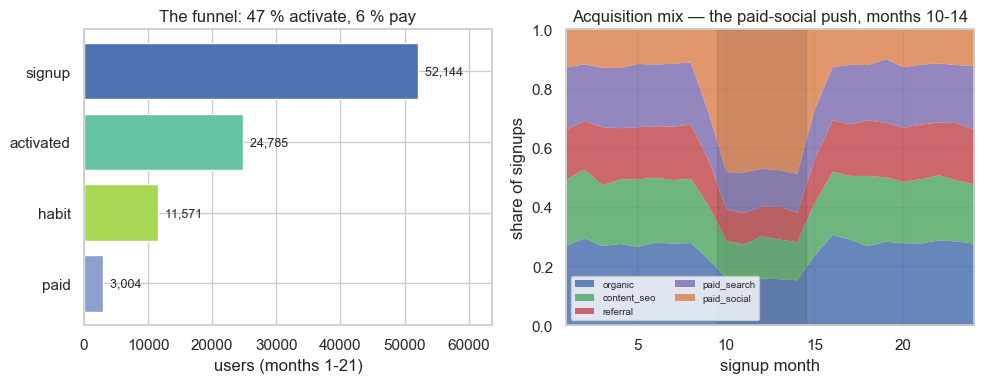

In [4]:
# FIG 1 -- the funnel, and the traffic that feeds it
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(steps.index[::-1], steps.users[::-1], color=["#8da0cb", "#a6d854", "#66c2a5", "#4c72b0"])
for y, (lab, v) in enumerate(list(zip(steps.index, steps.users))[::-1]):
    axes[0].text(v, y, f"  {v:,}", va="center", fontsize=9)
axes[0].margins(x=0.22)
axes[0].set_xlabel("users (months 1-21)")
axes[0].set_title("The funnel: 47 % activate, 6 % pay")

mix_month = pd.crosstab(signups.signup_month, signups.channel, normalize="index")
mix_month[CHANNELS].plot.area(ax=axes[1], color=["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#dd8452"],
                              alpha=0.85, lw=0)
axes[1].axvspan(9.5, 14.5, color="k", alpha=0.10)
axes[1].set_xlim(1, 24); axes[1].set_ylim(0, 1)
axes[1].set_xlabel("signup month"); axes[1].set_ylabel("share of signups")
axes[1].set_title("Acquisition mix — the paid-social push, months 10-14")
axes[1].legend(fontsize=7, loc="lower left", ncol=2)
plt.tight_layout()

Two pictures, one plot each, and they are about to fight.

The left panel is the funnel everyone in the company has seen: a bit under half of signups activate, roughly half of those form a habit, a quarter of those pay. The **biggest single leak is the first step** — more users are lost between signup and activation than at the other two steps combined — which is why every roadmap in every self-serve company starts with "fix onboarding". Hold that thought until §5, where we price it.

The right panel is the thing the funnel chart never shows you: **who the 60,000 are**. The shaded band is the paid-social push. During those five months the mix of arriving traffic changed more than the product did in two years — and every conversion rate in the left panel is a ratio whose denominator just got refilled with different people.

## 2. The funnel that got worse without anything getting worse

Month 10 lands and the weekly product review turns grim. Activation falls. Then habit formation falls. Then paid conversion falls. Three independent steps, three simultaneous declines — that pattern is what a genuinely broken release looks like, and the on-call rotation, the release notes and the error dashboards all get read very carefully for five months.

Let's reproduce the chart that started the panic.

In [5]:
def step_rates(frame):
    """Step conversion within a frame (a period, a channel, or both)."""
    return pd.Series({"signup->activated": frame.act.mean(),
                      "activated->habit": frame.hab.sum() / max(frame.act.sum(), 1),
                      "habit->paid": frame.pay.sum() / max(frame.hab.sum(), 1),
                      "signup->paid": frame.pay.mean()})

by_month = fun.groupby("signup_month").apply(step_rates, include_groups=False)
by_month.insert(0, "signups", fun.groupby("signup_month").size())

PERIODS = [("months 1-9 (before)", range(1, 10)),
           ("months 10-14 (push)", range(10, 15)),
           ("months 16-21 (after v2)", range(16, 22))]
raw = pd.DataFrame({lab: step_rates(fun[fun.signup_month.isin(mm)]) for lab, mm in PERIODS})

print("RAW step conversion, by period (%)  <- the panic chart, in a table\n")
print(raw.mul(100).round(1).to_string())
print(f"\nsignup->paid fell {(raw.iloc[3, 0] - raw.iloc[3, 1]) * 100:.2f} pp during the push "
      f"-- a {(1 - raw.iloc[3, 1] / raw.iloc[3, 0]) * 100:.0f} % relative collapse.")

RAW step conversion, by period (%)  <- the panic chart, in a table

                   months 1-9 (before)  months 10-14 (push)  months 16-21 (after v2)
signup->activated                 47.5                 40.4                     56.0
activated->habit                  45.8                 42.3                     51.4
habit->paid                       26.7                 24.5                     26.2
signup->paid                       5.8                  4.2                      7.5

signup->paid fell 1.63 pp during the push -- a 28 % relative collapse.


Every step down at once. Before you open the release notes, ask the question this module has asked in five different costumes now: **how did this data come to exist?** A conversion rate is `converted / arrived`, and the growth team spent months 10–14 changing *who arrived*.

The test is mechanical. Compute each step's conversion **within every channel separately**. If the product broke, the rates fall inside every channel. If the mix shifted, the within-channel rates hold still and only the *blend* moves.

In [6]:
within = pd.DataFrame({
    f"{lab} | {ch}": step_rates(fun[(fun.signup_month.isin(mm)) & (fun.channel == ch)])
    for lab, mm in PERIODS[:2] for ch in ["organic", "paid_social"]})
print("signup->activated, WITHIN channel (the two extremes)\n")
print(within.loc[["signup->activated", "activated->habit"]].mul(100).round(1).to_string())

share = pd.DataFrame({lab: fun[fun.signup_month.isin(mm)].channel.value_counts(normalize=True)
                      for lab, mm in PERIODS})
print("\nacquisition mix\n")
print(share.mul(100).round(1).to_string())

signup->activated, WITHIN channel (the two extremes)

                   months 1-9 (before) | organic  months 1-9 (before) | paid_social  months 10-14 (push) | organic  months 10-14 (push) | paid_social
signup->activated                           53.2                               26.1                           53.3                               28.5
activated->habit                            48.6                               28.8                           50.8                               30.1

acquisition mix

             months 1-9 (before)  months 10-14 (push)  months 16-21 (after v2)
channel                                                                       
content_seo                 21.5                 13.1                     21.8
organic                     27.1                 15.6                     28.4
paid_search                 20.1                 12.9                     19.9
paid_social                 13.8                 47.9                     11.7
refe

In [7]:
# ---- the mix-adjusted (segment-weighted) funnel ----
# Reference mix = the pre-push blend (months 1-9). Every period's channel-level rates
# are re-weighted to THAT blend, so the only thing left moving is the product.
REF_MIX = fun[fun.signup_month <= 9].channel.value_counts(normalize=True)

def mix_adjusted(frame, ref=REF_MIX):
    per_channel = frame.groupby("channel").apply(step_rates, include_groups=False)
    return (per_channel.mul(ref, axis=0).sum() / ref.sum())

adj = pd.DataFrame({lab: mix_adjusted(fun[fun.signup_month.isin(mm)]) for lab, mm in PERIODS})
compare = pd.concat({"raw": raw, "mix-adjusted": adj}, axis=1).swaplevel(axis=1).sort_index(axis=1)
print("RAW vs MIX-ADJUSTED step conversion (%)\n")
print(compare.mul(100).round(1).to_string())
print(f"\nsignup->activated during the push:  raw {raw.loc['signup->activated', PERIODS[1][0]]*100:.1f} % "
      f"vs mix-adjusted {adj.loc['signup->activated', PERIODS[1][0]]*100:.1f} % "
      f"(before: {raw.loc['signup->activated', PERIODS[0][0]]*100:.1f} %)")

RAW vs MIX-ADJUSTED step conversion (%)

                  months 1-9 (before)       months 10-14 (push)       months 16-21 (after v2)      
                         mix-adjusted   raw        mix-adjusted   raw            mix-adjusted   raw
signup->activated                47.5  47.5                48.4  40.4                    55.4  56.0
activated->habit                 44.5  45.8                45.9  42.3                    50.0  51.4
habit->paid                      25.8  26.7                25.1  24.5                    25.1  26.2
signup->paid                      5.8   5.8                 5.9   4.2                     7.4   7.5

signup->activated during the push:  raw 40.4 % vs mix-adjusted 48.4 % (before: 47.5 %)


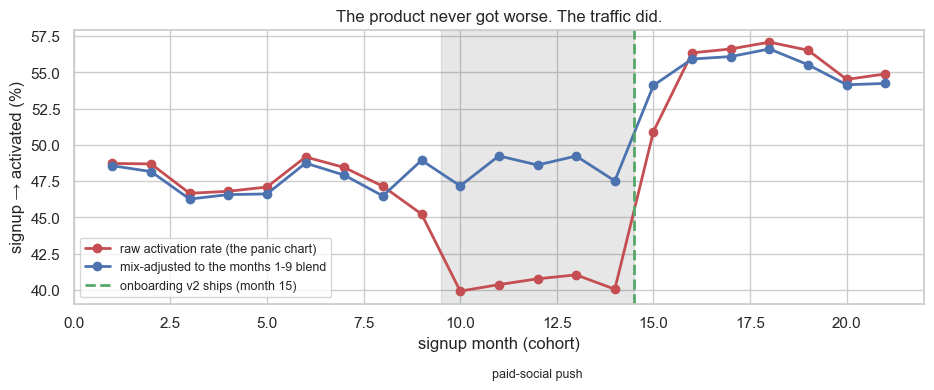

In [8]:
# FIG 2 -- the same months, two honest ways to read them
adj_by_month = pd.DataFrame(
    {m: mix_adjusted(fun[fun.signup_month == m]) for m in by_month.index}).T

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(by_month.index, by_month["signup->activated"] * 100, "-o", color="#c44e52", lw=2,
        label="raw activation rate (the panic chart)")
ax.plot(adj_by_month.index, adj_by_month["signup->activated"] * 100, "-o", color="#4c72b0", lw=2,
        label="mix-adjusted to the months 1-9 blend")
ax.axvspan(9.5, 14.5, color="k", alpha=0.10)
ax.text(12, 34, "paid-social push", ha="center", fontsize=9)
ax.axvline(14.5, color="#55a868", ls="--", lw=2, label="onboarding v2 ships (month 15)")
ax.set_xlabel("signup month (cohort)"); ax.set_ylabel("signup → activated (%)")
ax.set_title("The product never got worse. The traffic did.")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()

The blue line is the answer to the quarterly review's first question, and it is not the answer the room expected.

**Nothing broke.** Within every channel, activation held — organic went **53.2 % → 53.3 %**, paid social **26.1 % → 28.5 %** — and the drop in the red line is the blend moving underneath it: paid social went from **13.8 % of signups to 47.9 %**, and paid-social users activate at roughly *half* the rate of organic ones. Re-weight every month to the pre-push blend and the push months come out **level with, or slightly above, the months before them**: activation **47.5 % → 48.4 %** like-for-like, against **47.5 % → 40.4 %** raw. Five months of release-note archaeology looked for a bug that was never there.

You have seen this shape before. A8's Debug-me was a Simpson's-paradox costume drama (lot sizes fell, so the basket got dearer while every price got cheaper). This is the same algebra in a different costume, and it is worth naming once and then moving on, because the interesting part of §2 is not the paradox — it is *where the paradox comes from*. A funnel rate is a **ratio whose denominator has a marketing department attached to it**. Nobody has to make a mistake for it to move. The product org will be held to a number that the growth org controls, every quarter, forever, unless somebody publishes the mix-adjusted line next to the raw one.

> ⚠️ **The honest statement, in the words the review needs.** *"Activation fell 7.1 pp because we bought a different kind of traffic, not because the product regressed. Like-for-like it rose 0.9 pp. The push was still a bad idea — §5 prices it at −€22.8k — but the reason is payback, not onboarding."*

---

### ✋ Quick exercise (~2 min) — mix-adjust a funnel by hand

HelpDeskAI's sister product reports its activation rate by quarter. Two segments, two quarters:

| segment | Q1 signups | Q1 activation | Q2 signups | Q2 activation |
|---|---|---|---|---|
| enterprise trial | 8,000 | 55 % | 4,000 | 56 % |
| free-tool traffic | 2,000 | 25 % | 6,000 | 26 % |

Compute (a) the **raw** blended activation rate in each quarter, (b) the change, and (c) the **Q2 rate re-weighted to Q1's mix**. Then write the one sentence you would put on the slide.

In [9]:
# ✍️ Your turn 👇
# (a) raw_q1 = (8000 * 0.55 + 2000 * 0.25) / 10000
# (b) raw_q2 = ...
# (c) adjusted_q2 = q1_share_enterprise * 0.56 + q1_share_free * 0.26
q1 = {"enterprise": (8000, 0.55), "free": (2000, 0.25)}
q2 = {"enterprise": (4000, 0.56), "free": (6000, 0.26)}

<details>
<summary>✅ <b>Solution</b></summary>

```python
raw_q1 = sum(n * r for n, r in q1.values()) / sum(n for n, _ in q1.values())
raw_q2 = sum(n * r for n, r in q2.values()) / sum(n for n, _ in q2.values())
w1 = {k: n / sum(n for n, _ in q1.values()) for k, (n, _) in q1.items()}
adj_q2 = sum(w1[k] * r for k, (_, r) in q2.items())
print(f"raw:      Q1 {raw_q1:.1%} -> Q2 {raw_q2:.1%}   ({(raw_q2 - raw_q1) * 100:+.1f} pp)")
print(f"Q1-mixed: Q1 {raw_q1:.1%} -> Q2 {adj_q2:.1%}   ({(adj_q2 - raw_q1) * 100:+.1f} pp)")
```

Raw: **49.0 % → 38.0 %, a −11.0 pp collapse**. Re-weighted to Q1's mix: **49.0 % → 50.0 %, +1.0 pp**. Both segments got *better*; the blend got worse because the cheap segment tripled. The slide sentence: *"Activation is up 1 pp like-for-like. The blended rate is down 11 pp because free-tool traffic went from 20 % to 60 % of signups — that is an acquisition decision, and it should be judged on payback, not on activation."* Note what the adjustment is **not**: it is not a claim that the free-tool traffic doesn't count. Those users are real and they cost real money. It is a claim about *which team's number this is*.
</details>

## 3. Cohort retention curves, and the trap of the young cohort

Question two: **is the product actually getting better?** Funnel steps only measure the first twelve weeks. The thing a product org lives or dies by is whether people are still there in month six, and that is a **retention curve**: for each cohort, the share still weekly-active at age *w*.

The word "age" is doing all the work. A cohort's retention is only comparable to another cohort's **at the same age** — week 4 against week 4, week 26 against week 26 — because retention is a function of how long you have had the chance to leave. Arrange it as a **cohort triangle**: rows are cohorts, columns are ages, and the triangle is genuinely triangular, because the newest cohorts have not been alive long enough to fill the right-hand columns.

In [10]:
AGES = [0, 1, 2, 4, 8, 12, 16, 26, 39, 52]

def cohort_retention(g, w):
    """Share of a cohort still weekly-active at age w -- or NaN if we have not
    watched the whole cohort that long yet. Refusing to fill the cell IS the method."""
    return (g.life_weeks >= w).mean() if g.age_weeks.min() >= w else np.nan

triangle = pd.DataFrame(
    {f"w{w}": signups.groupby("signup_month").apply(cohort_retention, w, include_groups=False)
     for w in AGES})
print("COHORT TRIANGLE -- share still weekly-active at age w (blank = not observed yet)\n")
print(triangle.mul(100).round(1).to_string(na_rep="  ."))

COHORT TRIANGLE -- share still weekly-active at age w (blank = not observed yet)



                 w0    w1    w2    w4    w8   w12   w16   w26   w39   w52
signup_month                                                             
1             100.0  54.8  50.4  44.5  36.0  32.1  29.2  25.4  23.0  22.4
2             100.0  57.9  54.2  48.9  40.6  36.3  32.8  29.2  26.5  25.6
3             100.0  57.6  53.7  48.0  40.5  35.9  32.7  29.0  26.7  25.6
4             100.0  56.5  53.9  49.2  40.8  35.8  32.8  28.8  26.4  25.4
5             100.0  56.2  52.1  46.3  38.5  33.8  31.1  27.3  24.9  24.1
6             100.0  55.1  51.0  46.0  37.8  33.1  30.3  27.1  24.7  24.0
7             100.0  57.2  54.1  48.2  40.2  35.3  32.6  28.7  26.7  25.8
8             100.0  54.6  51.4  45.6  37.6  33.3  30.4  27.0  25.4  24.2
9             100.0  52.4  48.5  42.6  34.5  30.8  28.6  25.2  23.1  22.6
10            100.0  46.6  42.7  37.1  29.4  25.5  22.8  19.4  17.9  17.2
11            100.0  47.0  43.2  37.7  30.0  26.2  23.4  20.1  18.8  17.9
12            100.0  47.5  43.4  37.4

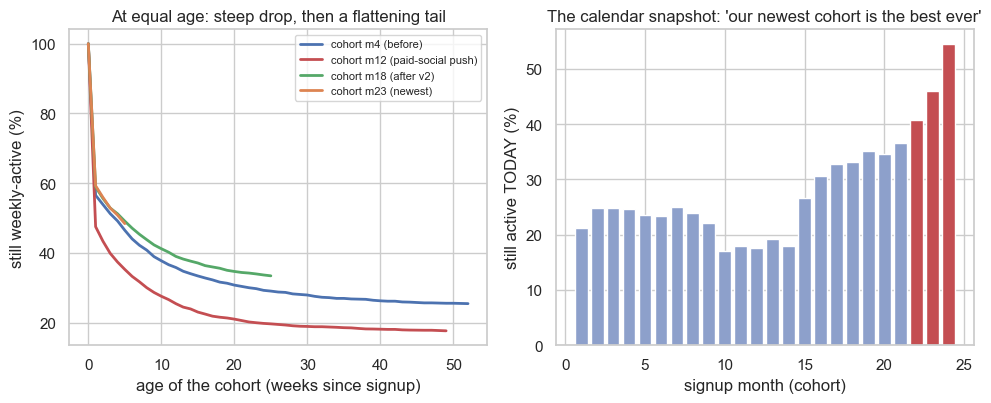

In [11]:
# FIG 3 -- the only honest comparison (left) and the dashboard everyone builds (right)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

curve_ages = np.arange(0, 53)
for m, color, lab in [(4, "#4c72b0", "cohort m4 (before)"),
                      (12, "#c44e52", "cohort m12 (paid-social push)"),
                      (18, "#55a868", "cohort m18 (after v2)"),
                      (23, "#dd8452", "cohort m23 (newest)")]:
    g = signups[signups.signup_month == m]
    r = [(g.life_weeks >= w).mean() if g.age_weeks.min() >= w else np.nan for w in curve_ages]
    axes[0].plot(curve_ages, np.array(r) * 100, lw=2, color=color, label=lab)
axes[0].set_xlabel("age of the cohort (weeks since signup)")
axes[0].set_ylabel("still weekly-active (%)")
axes[0].set_title("At equal age: steep drop, then a flattening tail")
axes[0].legend(fontsize=8)

snapshot = signups.assign(alive=(signups.life_weeks >= signups.age_weeks).astype(int)) \
                  .groupby("signup_month").alive.mean()
axes[1].bar(snapshot.index, snapshot * 100, color=["#8da0cb"] * 21 + ["#c44e52"] * 3)
axes[1].set_xlabel("signup month (cohort)")
axes[1].set_ylabel("still active TODAY (%)")
axes[1].set_title("The calendar snapshot: 'our newest cohort is the best ever'")
plt.tight_layout()

**Left panel — the shape every subscription product has.** A steep drop over the first four to eight weeks, then a bend, then a long flat tail. That flattening is not noise: it is a **mixture**. The population is not one kind of user churning at a constant rate; it is a blend of people who were never going to stick (gone by week 2) and people who have made the product part of their week (essentially permanent). As the first group drains away, the survivors are increasingly the second group, so the *observed* hazard falls with age. That is why the curve "smiles" — and why a constant-churn CLV (NB 23's `1/c`) systematically understates the value of anyone who survives the first month.

**Right panel — the chart that gets built instead.** "Percent of each cohort still active today" is what falls out of a `GROUP BY signup_month` against the current sessions table, and it says the newest cohort is the best in company history by a mile. It is nonsense. Cohort 23 has been alive for a handful of weeks; almost nobody has had *time* to churn. Read the bars right to left and you are essentially reading the retention curve backwards, one cohort per point.

This is **right-censoring**, and you met it in A5 §2 under exactly that name: the observation that hasn't finished happening. A5's version was employees who have not left *yet*; this one is cohorts that have not aged *yet*. Same disease, same cure — never compare units observed for different lengths of time, and refuse to fill the cells you cannot fill.

---

### 🔮 Predict the output

The next cell answers *"did the month-15 onboarding release improve retention?"* three ways at once: with the calendar snapshot, with week-12 retention at equal age, and with week-12 at equal age **and** mix-adjusted. All three will say *yes*. One of them will say it by roughly **double** what the other two say. Commit to which one, and to why — then check the sign of the gap between the push period's second and third columns, which is §2 arriving in retention clothing.

In [12]:
def w12(frame):
    return (frame.life_weeks >= 12).mean()

def mix_adjusted_w12(frame, ref=REF_MIX):
    per_channel = frame.groupby("channel").apply(w12, include_groups=False)
    return (per_channel * ref).sum() / ref.sum()

rows = []
for lab, mm in PERIODS:
    g = signups[signups.signup_month.isin(mm)]
    rows.append({"period": lab, "cohort n": len(g),
                 "BASELINE snapshot today": g.pipe(lambda x: (x.life_weeks >= x.age_weeks).mean()),
                 "week-12 (equal age)": w12(g),
                 "week-12, mix-adjusted": mix_adjusted_w12(g)})
verdict = pd.DataFrame(rows).set_index("period")
print(verdict.assign(**{c: verdict[c].map("{:.1%}".format) for c in verdict.columns[1:]}).to_string())

lift = mix_adjusted_w12(signups[signups.signup_month.isin(PERIODS[2][1])]) \
     - mix_adjusted_w12(signups[signups.signup_month.isin(PERIODS[0][1])])
print(f"\nonboarding v2, like-for-like at equal age : {lift * 100:+.1f} pp of week-12 retention")
print(f"same question via the BASELINE snapshot   : "
      f"{(verdict.iloc[2, 1] - verdict.iloc[0, 1]) * 100:+.1f} pp  <- inflated by censoring")

                         cohort n BASELINE snapshot today week-12 (equal age) week-12, mix-adjusted
period                                                                                             
months 1-9 (before)         17082                   23.7%               34.0%                 34.0%
months 10-14 (push)         18314                   17.9%               26.0%                 34.5%
months 16-21 (after v2)     14482                   33.8%               39.1%                 38.4%

onboarding v2, like-for-like at equal age : +4.4 pp of week-12 retention
same question via the BASELINE snapshot   : +10.2 pp  <- inflated by censoring


Three columns, three different answers to "is the product improving", and only one of them is admissible.

- The **calendar snapshot** — the baseline dashboard — flatters the recent period, because the recent period is *younger*, full stop.
- **Week-12 retention at equal age** is honest about age but still contaminated by §2's problem: the push cohorts sit at **26.0 %** against the pre-push **34.0 %**, purely because half of them came from paid social.
- **Week-12 at equal age, mix-adjusted** is the number the review should see. It puts the push cohorts at **34.5 %** — *fine*, once you compare them to the traffic they actually were — and it prices the month-15 onboarding at **+4.4 pp** of week-12 retention, on top of the activation gain §2 already found.

The baseline dashboard would have credited that release with **+10.2 pp**, more than twice the truth, because the "after" period is younger than the "before" period and nothing else. Note how much machinery it took to say something this small: two adjustments, one refusal to fill a table cell, and a number that would fit in a tweet. Most of product analytics is like this.

---

### ✋ Quick exercise (~2 min) — read one cell of the triangle

Look at the printed cohort triangle above.

1. Say in one sentence what the cell at row **month 12**, column **w26** means — including who is in the denominator.
2. Row **month 21** has a value at `w12` but a blank at `w26`. Why is the blank there, and what would happen to the column average if you filled it with the users who *have* reached 26 weeks?
3. Which single column would you put on the quarterly-review slide if you were allowed exactly one, and why?

In [13]:
# ✍️ Your turn 👇  (reasoning exercise -- write your three answers as comments,
# then use the triangle to check yourself)
# 1.
# 2.
# 3.
print(triangle.loc[[12, 21], ["w12", "w26"]].mul(100).round(1).to_string(na_rep="  ."))

               w12   w26
signup_month            
12            25.4  19.5
21            38.5     .


<details>
<summary>✅ <b>Solution</b></summary>

```python
n12 = (signups.signup_month == 12).sum()
n21 = (signups.signup_month == 21).sum()
print(f"m12 cohort: {n12:,} signups; the w26 cell is the share of ALL {n12:,} still active at age 26 w")
print(f"m21 cohort: {n21:,} signups; oldest member is {signups[signups.signup_month == 21].age_weeks.max()} "
      f"weeks old, youngest {signups[signups.signup_month == 21].age_weeks.min()} -> no w26 cell exists")
full = signups[signups.signup_month == 21]
print(f"if you filled it anyway with only the {(full.age_weeks >= 26).sum():,} rows old enough, "
      f"you would be averaging a self-selected slice of one month")
```

1. *"Of the users who signed up in month 12, this share were still weekly-active 26 weeks after **their own** signup date."* The denominator is the **whole cohort** — including everyone who churned in week 1. That is what makes it comparable to month 4's w26 cell.
2. The blank is there because month 21's cohort is younger than 26 weeks at the observation date, so the event "survived to 26 weeks" has not had the chance to happen or not happen. Filling it with only the rows that *are* old enough would silently switch the denominator to the earliest-signing slice of that month — a smaller, non-random subset — and it would drag the column average toward whatever that slice happens to be. Refusing to compute the cell is the correct behaviour, exactly as A5's Kaplan–Meier refuses to extend a curve past the last observed risk set.
3. **`w12`** — it is the longest horizon for which every cohort back to month 1 *and* every cohort you want to talk about (through month 21) has a complete answer. Choosing the retention horizon is choosing how long you are willing to wait to learn anything; `w26` is a better metric and a worse dashboard.
</details>

## 4. The activation metric — the one the team gets held to

Question three, and the expensive one. The growth PM opens with a slide:

> *"Users who invite 3 teammates in their first week retain almost 3× better at week 12. Invites are our activation metric. Next quarter the squad's goal is to get 40 % of new signups to invite 3 teammates."*

The slide is not exaggerating. The number is **2.75×**.

The correlation is real — we are about to reproduce it — and the proposal is the single most common product-analytics mistake in the industry. Watch the shape of it: a metric that **predicts** the outcome is being promoted to a metric the team **moves**, and those are not the same kind of object.

In [14]:
metric = signups.assign(retained_w12=(signups.life_weeks >= 12).astype(int))
raw_gap = metric.groupby("inviter").agg(users=("retained_w12", "size"),
                                        retained_w12=("retained_w12", "mean"))
raw_gap.index = ["invited < 3", "invited 3+"]
print(raw_gap.assign(retained_w12=raw_gap.retained_w12.map("{:.1%}".format)).to_string())
d_raw = raw_gap.retained_w12.iloc[1] - raw_gap.retained_w12.iloc[0]
print(f"\ninviters are {raw_gap.retained_w12.iloc[1] / raw_gap.retained_w12.iloc[0]:.2f}x more likely "
      f"to be around at week 12  ({d_raw * 100:+.1f} pp)")
print(f"share of signups who invite 3+ today: {signups.inviter.mean():.1%}")

             users retained_w12
invited < 3  51124        26.6%
invited 3+    8876        73.2%

inviters are 2.75x more likely to be around at week 12  (+46.5 pp)
share of signups who invite 3+ today: 14.8%


There it is: the slide is *true*. Now run the drill A4 taught, in its three escalating steps.

**Step 1 — name the confounder.** Why does someone invite three teammates in week one? Because they already decided this product is going to be part of how their team works. Inviting is not the cause of that decision; it is a **symptom** of it. The latent variable A4 called selection and NB 23 called persuadability is here called **intent**, and it drives both columns.

**Step 2 — adjust for what you measured.** HelpDeskAI's event stream has honest proxies for intent that are all observable *before or alongside* the invites: active days in week 1, sessions, docs read, whether the profile was completed, whether an inbox integration was connected, team size, and the acquisition channel. Compare inviters and non-inviters *who look the same on all of those*.

In [15]:
PROXIES = ["team_size", "active_days_w1", "sessions_w1", "docs_read",
           "profile_done", "integration", "activated", "habit"]
X = pd.concat([pd.get_dummies(metric[["channel"]], drop_first=True),
               metric[PROXIES + ["inviter"]]], axis=1)
adj_model = HistGradientBoostingClassifier(random_state=0).fit(X, metric.retained_w12)

X1, X0 = X.copy(), X.copy()
X1["inviter"], X0["inviter"] = 1, 0
adj_gap = (adj_model.predict_proba(X1)[:, 1] - adj_model.predict_proba(X0)[:, 1]).mean()

print(f"raw gap                       : {d_raw * 100:+5.1f} pp")
print(f"adjusted for measured intent  : {adj_gap * 100:+5.1f} pp")
print(f"...so {(1 - adj_gap / d_raw) * 100:.0f} % of the headline gap was the kind of user, "
      f"not the act of inviting.")

raw gap                       : +46.5 pp
adjusted for measured intent  :  +8.0 pp
...so 83 % of the headline gap was the kind of user, not the act of inviting.


The gap collapses from **+46.5 pp to +8.0 pp**: **83 %** of "3× better retention" was never about invitations — it was intent, measured badly and attributed to the nearest visible behaviour.

And now A4's warning, which is the whole reason step 3 exists: **the residual is not proof.** Adjustment buys you *"causal effects, provided treatment depended only on measured variables"*, and here "treatment" is a **user's own decision**, taken for reasons in their head — a budget approval, a mandate from their VP, a competing tool's outage. Not one of those is a column. A4 §6 showed the same estimator returning the wrong *sign* when the assignment rule leaned on something unmeasured, with no warning in the output. So the honest reading of the adjusted number is *"at most this much, and possibly none of it."*

**Step 3 — move it on purpose.** The only way to find out what a metric does when you push it is to push it. Product ships an **invite nudge** — a dismissible in-product prompt during onboarding — to a random half of new signups for six months, and we read two things: what happened to the *metric*, and what happened to the *outcome*.

In [16]:
def nudge_experiment(n=15_000, seed=101, boost=1.00):
    """Six months of new signups, randomized 50/50 to the invite nudge.

    The nudge changes invite behaviour and NOTHING else -- exactly the intervention
    the PM is proposing. Any retention movement is therefore causal, by construction
    (A4 §3: randomization zeroes the selection term).
    """
    rng = np.random.default_rng(seed)
    mix = np.array([0.28, 0.22, 0.18, 0.20, 0.12])
    channel = rng.choice(CHANNELS, size=n, p=mix / mix.sum())
    intent = pd.Series(channel).map(INTENT_MU).to_numpy() + rng.normal(0, 0.85, n)
    team = np.clip(rng.gamma(2.0, 3.5, n).round(), 1, 60)
    act = (rng.random(n) < sigmoid(-0.30 + 1.05 * intent + 0.020 * (team - 6) + 0.35)).astype(int)
    hab = (act * (rng.random(n) < sigmoid(-0.55 + 0.90 * intent + 0.30))).astype(int)

    nudged = (rng.random(n) < 0.5).astype(int)                       # the coin flip
    inviter = (rng.poisson(np.exp(-0.80 + 1.25 * intent + 0.030 * team
                                  + boost * nudged)) >= 3).astype(int)
    q = sigmoid(0.35 - 1.00 * intent - 0.85 * act - 0.20 * inviter)
    s = sigmoid(-1.55 + 1.05 * intent + 0.55 * act + 0.50 * hab + 0.22 * inviter + 0.30)
    h = sigmoid(-1.95 - 0.35 * intent)
    u = rng.random(n)
    life = np.where(u < q, 0, np.where(u < q + (1 - q) * s, 10_000, rng.geometric(h, n)))
    return pd.DataFrame({"nudged": nudged, "inviter": inviter,
                         "retained_w12": (life >= 12).astype(int)})

nudge = nudge_experiment()
arms = nudge.groupby("nudged").agg(n=("retained_w12", "size"),
                                   inviter=("inviter", "mean"),
                                   retained_w12=("retained_w12", "mean"))
d_metric = arms.inviter.iloc[1] - arms.inviter.iloc[0]
d_outcome = arms.retained_w12.iloc[1] - arms.retained_w12.iloc[0]
se = np.sqrt(sum(arms.retained_w12 * (1 - arms.retained_w12) / arms.n))

print(arms.assign(inviter=arms.inviter.map("{:.1%}".format),
                  retained_w12=arms.retained_w12.map("{:.1%}".format))
          .rename(index={0: "control", 1: "nudged"}).to_string())
print(f"\nTHE METRIC : {d_metric * 100:+.1f} pp of signups now invite 3+   <- the nudge works, hugely")
print(f"THE OUTCOME: {d_outcome * 100:+.2f} pp of week-12 retention (95% CI +-{1.96 * se * 100:.2f} pp)")
print(f"\nwhat the 3x correlation predicted for this much metric movement: "
      f"{d_metric * d_raw * 100:+.1f} pp of retention")

            n inviter retained_w12
nudged                            
control  7527   17.8%        35.6%
nudged   7473   42.4%        37.5%

THE METRIC : +24.6 pp of signups now invite 3+   <- the nudge works, hugely
THE OUTCOME: +1.90 pp of week-12 retention (95% CI +-1.54 pp)

what the 3x correlation predicted for this much metric movement: +11.4 pp of retention


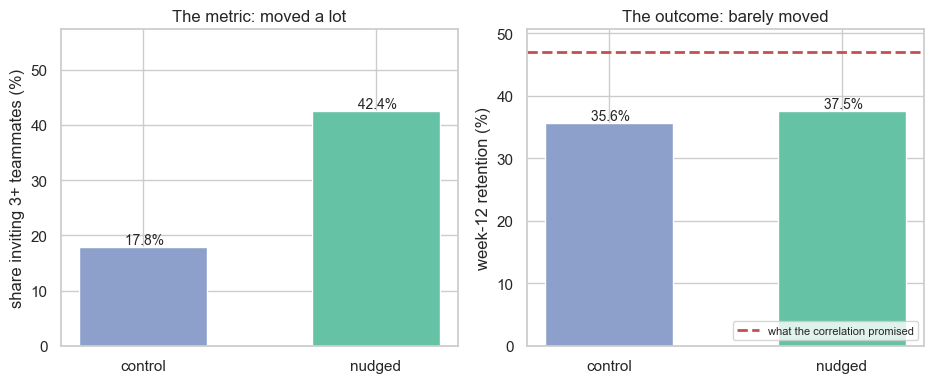

In [17]:
# FIG 4 -- the same intervention, measured on the metric and on the outcome
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, col, title, ylab in [
        (axes[0], "inviter", "The metric: moved a lot", "share inviting 3+ teammates (%)"),
        (axes[1], "retained_w12", "The outcome: barely moved", "week-12 retention (%)")]:
    vals = arms[col] * 100
    ax.bar(["control", "nudged"], vals, color=["#8da0cb", "#66c2a5"], width=0.55)
    for i, v in enumerate(vals):
        ax.text(i, v, f" {v:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.35); ax.set_ylabel(ylab); ax.set_title(title)
axes[1].axhline((arms.retained_w12.iloc[0] + d_metric * d_raw) * 100, color="#c44e52", ls="--", lw=2,
                label="what the correlation promised")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()

That dashed red line is the entire notebook in one mark. It is where week-12 retention *should* have landed if the 3× correlation had been a causal fact and the nudge had converted that many people into inviters. The green bar is where it actually landed.

State the lesson in the form a PM can act on:

> 🎯 **Diagnostic vs actionable.** A **diagnostic** metric *predicts* the outcome: it tells you which users are in trouble, and it is genuinely useful for triage, alerting, lead scoring and segmentation. An **actionable** metric *changes* the outcome when you move it. Every actionable metric is diagnostic; almost no diagnostic metric is actionable. Teams are routinely handed the first and held to it as if it were the second — for four quarters, with a bonus attached.

The test for which one you are holding is not statistical sophistication. Nothing about the correlation was wrong; the adjusted estimate was better and still not enough. **The test is an intervention.** A2 is the notebook that tells you whether you can afford one: at ~7,500 signups per arm this test resolves about **±1.5 pp**, which is plenty to kill the **+11.4 pp** the correlation promised — and nowhere near enough to pin down whether the truth is 0 pp or 2 pp. That second distinction matters for the *next* decision, not this one, and 🧠 Stretch C sizes it properly.

Note also what the experiment did **not** say: that invites are worthless. Inviting teammates is a fine *diagnostic* — it is one of the sharpest early signals of intent in the whole event stream, which is exactly why it correlated so well. Keep it on the health dashboard. Do not put it on the squad's OKR.

---

### ✋ Quick exercise (~2 min) — diagnostic or actionable?

For each metric, decide whether it is plausibly **actionable** (moving it moves the outcome) or only **diagnostic** (it predicts the outcome because of something upstream) — and name the upstream thing when it is only diagnostic.

1. *Users who connect an email integration in week 1 retain 2.4× better.*
2. *Users whose first ticket is resolved by the bot in under 30 seconds retain 1.6× better.*
3. *Accounts with more than 5 seats renew 2× more often.*
4. *Users who open the mobile app at least once retain 1.9× better.*

In [18]:
# ✍️ Your turn 👇  (reasoning exercise -- one line per metric)
# 1.
# 2.
# 3.
# 4.

<details>
<summary>✅ <b>Solution</b></summary>

```python
calls = [
    ("1 email integration", "MIXED",      "partly causal (it makes the product work) - test a forced-setup step"),
    ("2 fast first resolution", "ACTIONABLE", "latency is a product property you can ship; the user did not choose it"),
    ("3 more than 5 seats", "DIAGNOSTIC", "company size / budget - you cannot ship seats to a 2-person team"),
    ("4 opened mobile app", "DIAGNOSTIC", "habit already formed; the app is the symptom, not the cause"),
]
for name, verdict, why in calls:
    print(f"{name:26s} {verdict:11s} {why}")
```

The question that sorts them: **can the team move this metric without moving the user's intent — and if they do, does anything downstream follow?**

- **(2)** is the clean actionable one. First-resolution latency is a property of *your* system; users do not select into it, so the correlation is much closer to causal, and a latency budget is a shippable roadmap item.
- **(3)** is the clean diagnostic. Seat count is a fact about the customer's company. You can *select* for it in marketing (that is a real use — it belongs in lead scoring, A7 §5), but no engineering work makes a two-person team into a seven-person one.
- **(4)** is §4 all over again: mobile use is what an already-committed user does. Nudging everyone into the app will move the metric and, on the evidence of this notebook, roughly nothing else.
- **(1)** is the honest middle, and the most common case. There is a plausible causal path (without the integration the product genuinely cannot do its job) *and* a plausible selection path (only people who intend to commit go to the trouble). "Mixed" is not a cop-out — it is the correct answer, and it converts directly into a test: force the integration into onboarding for a random half and read the retention arm.
</details>

## 5. From curves to money — LTV, payback, and two roadmap items

Everything so far is percentages. The quarterly review runs on euros, so we convert — and the conversion is where the tail assumption from §3 stops being a technicality and starts being most of the answer.

**LTV from a retention curve.** A paying customer contributes `MARGIN_PM` for every month they stay. If `S(m)` is the share of payers still paying `m` months in, expected margin is just the area under that curve:

$$\text{LTV} = \text{margin} \times \sum_{m \ge 0} S(m)$$

We observe `S(m)` up to whatever age our oldest payers have reached — and then we *assume* the rest. The standard, defensible assumption is a constant monthly retention `r` from the last observed point onward, which turns the infinite tail into one geometric sum, $S(M)\cdot r/(1-r)$. NB 23 used the same constant-hazard idea for `1/c`; §3's smiling curve is the reason we apply it only to the **tail**, where the curve has already flattened, instead of to the whole life.

In [19]:
payers = signups[(signups.paid == 1) & (signups.t_paid <= OBS_WEEKS)].copy()
payers["start"] = payers.t_paid - payers.signup_week            # weeks from signup to first invoice
payers["observable_months"] = ((payers.age_weeks - payers.start) / 4).clip(lower=0)

def paid_survival(frame, max_m=18, min_n=60):
    """S(m) among the payers we have actually watched for m months.

    The `observable_months >= m` filter is A5's risk-set discipline in subscription
    clothing: a customer who started paying six weeks ago is evidence about month 1,
    and no evidence at all about month 12. We stop the curve where the risk set
    thins out rather than extending it on a handful of rows.
    """
    out = {}
    for m in range(max_m + 1):
        at_risk = frame[frame.observable_months >= m]
        if len(at_risk) < min_n:
            break
        out[m] = (at_risk.paid_months > m).mean()
    return pd.Series(out)

M_OBS = 12
S_paid = paid_survival(payers)
R_MONTHLY = (S_paid[M_OBS] / S_paid[M_OBS - 3]) ** (1 / 3)      # tail retention, months 9->12

observed_months = S_paid[:M_OBS + 1].sum()
tail_months = S_paid[M_OBS] * R_MONTHLY / (1 - R_MONTHLY)
LTV_PAYING = (observed_months + tail_months) * MARGIN_PM

print(f"{len(payers):,} payers; monthly paid retention in the tail: {R_MONTHLY:.3f}")
print(f"observed months (0-{M_OBS}) : {observed_months:5.2f}  ->  EUR {observed_months * MARGIN_PM:,.0f}")
print(f"assumed tail (m>{M_OBS})     : {tail_months:5.2f}  ->  EUR {tail_months * MARGIN_PM:,.0f}")
print(f"LTV per paying customer  : EUR {LTV_PAYING:,.0f}   "
      f"({tail_months / (observed_months + tail_months):.0%} of it is the assumption)")

4,333 payers; monthly paid retention in the tail: 0.906
observed months (0-12) :  8.23  ->  EUR 270
assumed tail (m>12)     :  3.17  ->  EUR 104
LTV per paying customer  : EUR 374   (28% of it is the assumption)


In [20]:
# ---- the same calculation per cohort group, each with its OWN observed window ----
tail_table = []
for lab, mm in PERIODS:
    g = payers[payers.signup_month.isin(mm)]
    Sg = paid_survival(g)
    m_obs = int(Sg.index.max())
    obs_e = Sg.sum() * MARGIN_PM
    tail_e = Sg.iloc[-1] * R_MONTHLY / (1 - R_MONTHLY) * MARGIN_PM
    tail_table.append({"cohort group": lab, "payers": len(g), "months observed": m_obs,
                       "observed EUR": obs_e, "tail EUR": tail_e,
                       "LTV EUR": obs_e + tail_e, "tail share": tail_e / (obs_e + tail_e)})
tail_table = pd.DataFrame(tail_table).set_index("cohort group")
print("LTV per paying customer, by cohort group -- and how much of it we have actually seen\n")
print(tail_table.assign(**{c: tail_table[c].map("{:,.0f}".format) for c in
                           ["observed EUR", "tail EUR", "LTV EUR"]},
                        **{"tail share": tail_table["tail share"].map("{:.0%}".format)}).to_string())

LTV per paying customer, by cohort group -- and how much of it we have actually seen

                         payers  months observed observed EUR tail EUR LTV EUR tail share
cohort group                                                                             
months 1-9 (before)        1398               18          319       58     376        15%
months 10-14 (push)        1094               12          270       98     368        27%
months 16-21 (after v2)    1428                6          182      161     342        47%


Read the last column before anything else. The pre-push cohorts have been paying long enough that only **15 %** of their €376 is extrapolation. The cohorts the review actually wants to celebrate — the ones that arrived *after* the month-15 release — have six months of payment history, so **47 % of "their LTV" is the tail assumption**, not data. And the three groups' LTVs (€376 / €368 / €342) look reassuringly similar precisely *because* they mostly share one assumed number.

That is not a reason to skip the calculation. It is a reason to publish `R_MONTHLY = 0.906` next to the LTV every time, and to treat a one-point change in the assumed tail retention as a bigger deal than most of the analysis above it (🧠 Stretch A quantifies exactly how much bigger).

Now the acquisition question. A channel is worth buying when the value of a signup exceeds what the signup cost — `LTV:CAC` — and the CFO adds a second, harsher test: **payback**, the number of months of gross margin it takes to get the cash back. A ratio can look fine while the payback is longer than your runway.

In [21]:
channel_econ = fun.groupby("channel").agg(signups=("pay", "size"), paid_rate=("pay", "mean"))
channel_econ["share of signups"] = channel_econ.signups / channel_econ.signups.sum()
channel_econ["CAC per signup"] = channel_econ.index.map(CAC)
channel_econ["LTV per signup"] = channel_econ.paid_rate * LTV_PAYING
channel_econ["LTV:CAC"] = np.where(channel_econ["CAC per signup"] > 0,
                                   channel_econ["LTV per signup"] / channel_econ["CAC per signup"], np.inf)
channel_econ["payback (months)"] = np.where(
    channel_econ["CAC per signup"] > 0,
    channel_econ["CAC per signup"] / (channel_econ.paid_rate * MARGIN_PM), 0.0)
channel_econ = channel_econ.sort_values("LTV:CAC")
print(channel_econ.assign(
    **{"share of signups": channel_econ["share of signups"].map("{:.1%}".format),
       "paid_rate": channel_econ.paid_rate.map("{:.1%}".format),
       "LTV per signup": channel_econ["LTV per signup"].map("EUR {:.2f}".format),
       "LTV:CAC": channel_econ["LTV:CAC"].map("{:.2f}".format),
       "payback (months)": channel_econ["payback (months)"].map("{:.1f}".format)}).to_string())

push = fun[(fun.signup_month.between(10, 14)) & (fun.channel == "paid_social")]
spend = len(push) * CAC["paid_social"]
value = len(push) * channel_econ.loc["paid_social", "LTV per signup"]
print(f"\nthe push itself: {len(push):,} paid-social signups in months 10-14")
print(f"  spend EUR {spend:,.0f}   ->   lifetime value EUR {value:,.0f}   "
      f"=  EUR {value - spend:,.0f}")

             signups paid_rate share of signups  CAC per signup LTV per signup LTV:CAC payback (months)
channel                                                                                                
paid_social    13436      1.7%            25.8%             9.0       EUR 6.40    0.71             16.0
paid_search     9062      5.3%            17.4%            16.0      EUR 19.72    1.23              9.2
content_seo     9642      6.4%            18.5%             6.0      EUR 23.84    3.97              2.9
referral        7860      9.4%            15.1%             4.0      EUR 35.01    8.75              1.3
organic        12144      7.8%            23.3%             0.0      EUR 29.09     inf              0.0

the push itself: 8,768 paid-social signups in months 10-14
  spend EUR 78,912   ->   lifetime value EUR 56,110   =  EUR -22,802


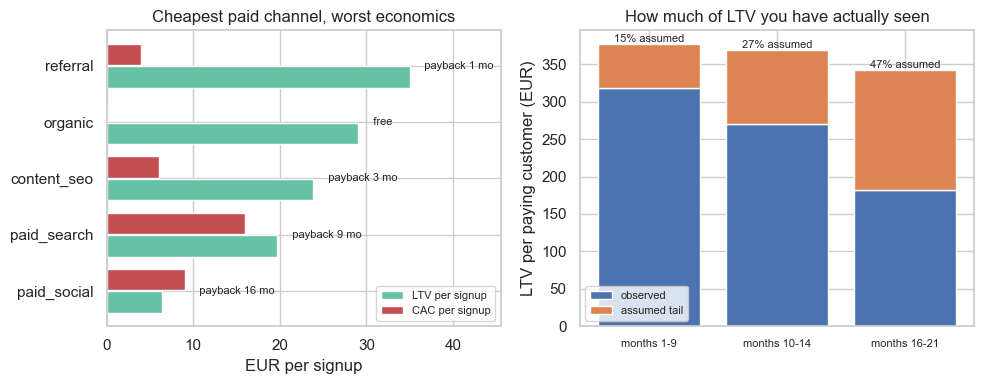

In [22]:
# FIG 5 -- value against cost, per signup, by channel
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ce = channel_econ.sort_values("LTV per signup")
y = np.arange(len(ce))
axes[0].barh(y - 0.2, ce["LTV per signup"], height=0.38, color="#66c2a5", label="LTV per signup")
axes[0].barh(y + 0.2, ce["CAC per signup"], height=0.38, color="#c44e52", label="CAC per signup")
axes[0].set_yticks(y); axes[0].set_yticklabels(ce.index)
for i, (l, c, p) in enumerate(zip(ce["LTV per signup"], ce["CAC per signup"], ce["payback (months)"])):
    axes[0].text(max(l, c) + 1, i, f"  payback {p:.0f} mo" if c > 0 else "  free", va="center", fontsize=8)
axes[0].margins(x=0.30)
axes[0].set_xlabel("EUR per signup"); axes[0].set_title("Cheapest paid channel, worst economics")
axes[0].legend(fontsize=8, loc="lower right")

tt = tail_table.reset_index()
axes[1].bar(range(len(tt)), tt["observed EUR"], color="#4c72b0", label="observed")
axes[1].bar(range(len(tt)), tt["tail EUR"], bottom=tt["observed EUR"], color="#dd8452",
            label="assumed tail")
axes[1].set_xticks(range(len(tt)))
axes[1].set_xticklabels([s.split("(")[0].strip() for s in tt["cohort group"]], fontsize=8)
for i, (o, t) in enumerate(zip(tt["observed EUR"], tt["tail EUR"])):
    axes[1].text(i, o + t, f"{t / (o + t):.0%} assumed", ha="center", va="bottom", fontsize=8)
axes[1].set_ylabel("LTV per paying customer (EUR)")
axes[1].set_title("How much of LTV you have actually seen")
axes[1].legend(fontsize=8)
plt.tight_layout()

The paid-social push was optimised on **cost per signup**, and on that metric it won: at **€9** it was the cheapest paid channel HelpDeskAI had, well under paid search's €16. On the metric that determines whether the company survives it is the worst thing in the table — **LTV:CAC of 0.71** and a **16-month payback**, against finance's 3.0 and 12 months — because a paid-social signup converts to paid at **1.7 %** where an organic one converts at 7.8 %. The five months of the push bought 8,768 signups for **€78,912** and will return **€56,110**: a **€22,802** hole, and 25.8 % of the last two years' signups.

This is §4's lesson in a second costume, one row up the org chart. Cost per signup is a **diagnostic** — a fine operational number for a media buyer optimising a bid inside a channel. It was promoted to the number the push was *judged* on, and moving it moved nothing downstream, because the cheapness came from buying weaker intent. The funnel decline in §2 and the money loss here have the same single cause; only one of them was blamed on the product team.

Now the roadmap, which is where all of this converts into a decision. Two candidate projects, both estimated at one squad-quarter, both promising **+5 percentage points** at a funnel step:

- **Project EARLY** — onboarding v3: +5 pp on `signup → activated`, the step with the biggest absolute leak.
- **Project LATE** — a paywall and trial-expiry redesign: +5 pp on `habit → paid`, the step almost nobody looks at.

In [23]:
post = fun[fun.signup_month.between(16, 21)]
r1, r2, r3 = step_rates(post)[["signup->activated", "activated->habit", "habit->paid"]]
RUN_RATE = signups[signups.signup_month.between(22, 24)].groupby("signup_month").size().mean()
YEARLY = RUN_RATE * 12
print(f"current funnel (months 16-21): {r1:.1%} -> {r2:.1%} -> {r3:.1%}; "
      f"run rate {RUN_RATE:,.0f} signups/month -> {YEARLY:,.0f}/year\n")

# --- naive pricing: assume the extra users behave like the average user ---
naive_early = YEARLY * 0.05 * r2 * r3
naive_late = YEARLY * r1 * r2 * 0.05
print(f"NAIVE (marginal user = average user)")
print(f"  EARLY +5 pp at signup->activated : {naive_early:6.0f} extra payers -> "
      f"EUR {naive_early * LTV_PAYING:>9,.0f}/yr")
print(f"  LATE  +5 pp at habit->paid       : {naive_late:6.0f} extra payers -> "
      f"EUR {naive_late * LTV_PAYING:>9,.0f}/yr")

current funnel (months 16-21): 56.0% -> 51.4% -> 26.2%; run rate 2,619 signups/month -> 31,424/year

NAIVE (marginal user = average user)
  EARLY +5 pp at signup->activated :    212 extra payers -> EUR    79,118/yr
  LATE  +5 pp at habit->paid       :    452 extra payers -> EUR   169,089/yr


In [24]:
# --- the marginal user is not the average user ---
# Rank users by an onboarding score built ONLY from measured signals, then read the
# downstream behaviour of the weakest fifth of each step's survivors. Those are the
# people a +5 pp improvement actually adds.
score_X = pd.concat([pd.get_dummies(fun[["channel"]], drop_first=True),
                     fun[["team_size", "active_days_w1", "sessions_w1", "docs_read",
                          "profile_done", "integration"]]], axis=1)
fun_s = fun.assign(score=HistGradientBoostingClassifier(random_state=0)
                   .fit(score_X, fun.act).predict_proba(score_X)[:, 1])

acts = fun_s[fun_s.act == 1]
marginal_act = acts[acts.score <= acts.score.quantile(0.20)]
habs = fun_s[fun_s.hab == 1]
marginal_hab = habs[habs.score <= habs.score.quantile(0.20)]
pays = fun_s[fun_s.pay == 1]
ltv_factor = pays[pays.score <= pays.score.quantile(0.30)].paid_months.mean() / pays.paid_months.mean()

m_r2 = marginal_act.hab.mean()
m_r3 = marginal_hab.pay.mean()
print(f"marginal activator : activated->habit {m_r2:.1%} (average {acts.hab.mean():.1%}), "
      f"then habit->paid {marginal_act.pay.sum() / max(marginal_act.hab.sum(), 1):.1%}")
print(f"marginal habit user: habit->paid {m_r3:.1%} (average {habs.pay.mean():.1%})")
print(f"marginal payer LTV : {ltv_factor:.0%} of the average payer's\n")

early = YEARLY * 0.05 * m_r2 * (marginal_act.pay.sum() / max(marginal_act.hab.sum(), 1))
late = YEARLY * r1 * r2 * 0.05
LTV_MARGINAL = LTV_PAYING * ltv_factor
roadmap = pd.DataFrame({
    "extra payers / yr": [early, late],
    "LTV each (EUR)": [LTV_MARGINAL, LTV_MARGINAL],
    "value / yr (EUR)": [early * LTV_MARGINAL, late * LTV_MARGINAL]},
    index=["EARLY  +5 pp signup->activated", "LATE   +5 pp habit->paid"])
print(roadmap.assign(**{"extra payers / yr": roadmap["extra payers / yr"].map("{:,.0f}".format),
                        "LTV each (EUR)": roadmap["LTV each (EUR)"].map("{:,.0f}".format),
                        "value / yr (EUR)": roadmap["value / yr (EUR)"].map("{:,.0f}".format)}).to_string())
print(f"\nLATE beats EARLY by {late * LTV_MARGINAL - early * LTV_MARGINAL:,.0f} EUR/yr "
      f"({late * LTV_MARGINAL / (early * LTV_MARGINAL):.1f}x) -- and EARLY is the leakiest step.")

marginal activator : activated->habit 26.9% (average 46.7%), then habit->paid 13.8%
marginal habit user: habit->paid 15.3% (average 26.0%)
marginal payer LTV : 72% of the average payer's

                               extra payers / yr LTV each (EUR) value / yr (EUR)
EARLY  +5 pp signup->activated                58            268           15,628
LATE   +5 pp habit->paid                     452            268          121,224

LATE beats EARLY by 105,596 EUR/yr (7.8x) -- and EARLY is the leakiest step.


The leakiest step loses. Three reasons, all of them worth carrying to the next roadmap argument you are in:

1. **Traffic.** Five points at the top of the funnel are five points of *everyone*, but those users still have to survive two more steps, each of which throws away half. Five points at the bottom are five points of a much smaller group who have already survived everything.
2. **Marginal quality.** The ~1,570 users a +5 pp onboarding win adds each year are, by construction, the ones who *nearly* activated and didn't — the weakest fifth of the step. They go on to form a habit at **26.9 %** against the average **46.7 %**, and then pay at **13.8 %** against **26.0 %**; the ones who do pay stay only **72 %** as long. Costing the change with average rates puts EARLY at **€79,118** instead of **€15,628** — a 5× overstatement, and the standard way an early-funnel project wins a roadmap argument it should lose.
3. **Distance to money.** Every step between an improvement and the invoice multiplies its value by a number smaller than one.

> ⚠️ **Two honest caveats, because this is a decision worth arguing about.** "Plus five points" is *the PM's* framing, and it is not neutral: +5 pp is a much larger relative move at a 26 % step than at a 56 % one, so part of LATE's win is that it was handed the easier-sounding target. And EARLY brings 1,500-odd extra activated users a year who are worth something even if they never pay — support deflection, word of mouth, a pool for later re-activation — none of which is in this model. The right output of this cell is not "never fix onboarding". It is *"here are both numbers, here is what each one assumes, now argue about the assumptions instead of about who is more passionate."*

In [25]:
# ---- and the price of getting §4 wrong ----
SQUAD_COST_PER_QUARTER = 6 * 3 * 9_500          # 6 people, 3 months, EUR 9.5k fully loaded
forgone = late * LTV_MARGINAL                    # the roadmap item the squad did NOT build
promised = d_metric * d_raw * 100                # pp of retention the correlation implied
delivered = d_outcome * 100

print(f"A quarter spent chasing the invite metric:")
print(f"  squad cost                              : EUR {SQUAD_COST_PER_QUARTER:>9,.0f}")
print(f"  forgone roadmap item (LATE, one year)   : EUR {forgone:>9,.0f}")
print(f"  total                                   : EUR {SQUAD_COST_PER_QUARTER + forgone:>9,.0f}")
print(f"\n  promised on the strength of the correlation: {promised:+.1f} pp of week-12 retention")
print(f"  delivered when the nudge actually shipped  : {delivered:+.2f} pp "
      f"(95% CI +-{1.96 * se * 100:.2f})")
print(f"\nThe experiment that would have prevented this cost one flag and six months of "
      f"patience -- and it is the same 50/50 split A2 §2 asks you to size BEFORE you build.")

A quarter spent chasing the invite metric:
  squad cost                              : EUR   171,000
  forgone roadmap item (LATE, one year)   : EUR   121,224
  total                                   : EUR   292,224

  promised on the strength of the correlation: +11.4 pp of week-12 retention
  delivered when the nudge actually shipped  : +1.90 pp (95% CI +-1.54)

The experiment that would have prevented this cost one flag and six months of patience -- and it is the same 50/50 split A2 §2 asks you to size BEFORE you build.


---

### ✋ Quick exercise (~2 min) — integrate a short curve into LTV

A smaller HelpDeskAI plan has only five months of paid history. Its observed monthly survival curve is

`S = [1.00, 0.78, 0.66, 0.60, 0.57]` for months 0–4,

the margin is **€19.90** per paying month, and the tail is assumed to retain at **r = 0.93** per month from month 4 onward. Compute the observed LTV, the tail LTV, the total, and **the share of the total that is assumption**. Then: if the true tail retention were 0.90 instead, how much LTV disappears?

In [26]:
# ✍️ Your turn 👇
S_small = [1.00, 0.78, 0.66, 0.60, 0.57]
margin_small = 19.90
r_tail = 0.93
# observed  = margin * sum(S_small)
# tail      = margin * S_small[-1] * r / (1 - r)

<details>
<summary>✅ <b>Solution</b></summary>

```python
def small_ltv(r):
    observed = margin_small * sum(S_small)
    tail = margin_small * S_small[-1] * r / (1 - r)
    return observed, tail

obs_e, tail_e = small_ltv(0.93)
print(f"observed (m0-4): EUR {obs_e:6.2f}")
print(f"assumed tail   : EUR {tail_e:6.2f}   ({tail_e / (obs_e + tail_e):.0%} of the total)")
print(f"LTV            : EUR {obs_e + tail_e:6.2f}")
for r in (0.90, 0.93, 0.95):
    o, t = small_ltv(r)
    print(f"  r = {r:.2f} -> LTV EUR {o + t:7.2f}")
```

Observed **€72.03**, tail **€150.75**, total **€222.78** — and **68 %** of the number is the assumption. Drop the tail retention from 0.93 to 0.90 and LTV falls to **€173.13**, a **22 % cut**, from changing one digit nobody in the meeting will question. The general shape: the tail term is $S(M)\,r/(1-r)$, and $r/(1-r)$ explodes as `r → 1` — 0.90 buys 9 months, 0.95 buys 19, 0.98 buys 49. This is why "what monthly retention did you assume?" is the only LTV question worth asking first, and why 🧠 Stretch A puts a band on it instead of a point.
</details>

## 6. What real product-analytics teams add (honest section)

Everything above is the analysis. In a real product org it is maybe a third of the job, and not the hard third.

- **The event taxonomy and the tracking plan.** This notebook was handed clean `activated` / `habit` / `paid` flags with timestamps. In production nobody hands you those; somebody has to *define* them, get engineering to instrument them identically on web, iOS and Android, keep the definitions stable through three refactors, and detect the release where `signup_completed` silently stopped firing on Safari. **Instrumenting reliably beats modelling cleverly**, by a wide margin and every quarter. The deliverable is a versioned tracking plan (event names, properties, owners, a schema test in CI) — deeply unglamorous, and the difference between a data team that is trusted and one that is not.
- **Identity stitching.** One human reads a blog post logged out on a phone, signs up on a laptop, and later logs in through their employer's SSO. That is three identifiers and one cohort membership. Getting it wrong inflates signups, corrupts every funnel denominator in §2, and puts the same person in two cohorts in §3.
- **Session and metric definitions that survive politics.** "Weekly active" sounds objective until you ask whether an API call counts, whether a bot-triggered event counts, whether opening an email counts. Every one of those choices moves the north-star metric by more than most releases do, and the choice usually gets made in the quarter it flatters someone.
- **North-star metric politics.** §4 was about whether a metric is causal. The other half is organisational: a north star that the product team cannot move (revenue, in a company where pricing sits in finance) produces theatre; a north star that is trivially movable produces §4. The workable ones are downstream enough to matter and upstream enough to be shippable.
- **Goodhart, on a timer.** A7 §6 said it for sales reps: the moment stage conversion feeds a forecast or a bonus, the stages get gamed. Product is identical. Ship a nudge that counts invites and you will get invites — to nonexistent colleagues, to personal addresses, to the same three teammates twice. *When a measure becomes a target, it ceases to be a good measure*, and the countermeasures are the same as A7's: define the event by a verifiable outcome (invite **accepted**, not invite **sent**), pair every target metric with a guardrail metric, and re-validate the correlation after the target is set, because the relationship you measured was measured on unincentivised behaviour. 🧠 Stretch D simulates the whole cycle in twenty lines.
- **Consent, and a shrinking event stream.** Under GDPR/ePrivacy a meaningful share of your users never enter the analytics dataset at all, and the share is *not random* — it correlates with device, region, and technical sophistication, which is to say with intent. Cohort sizes drift when a consent banner changes. Server-side event collection for product analytics (as opposed to marketing attribution) is the standard answer, along with retention limits that quietly truncate exactly the long tails §5 depends on.
- **What this notebook did not solve.** We never modelled *which* users will churn (that is NB 23, and it belongs downstream of here); we never touched multi-touch attribution, which is where the CAC numbers in §5 come from and where most of the arguing happens; and every euro in §5 rests on `R_MONTHLY`, a single number estimated from three months of one cohort group.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | 60,000 signups, one 12-week conversion window, 52,144 usable | 47.5 % activate · 46.7 % form a habit · 26.0 % pay |
| 2 | Three funnel steps fall together for five months | signup→paid **5.8 % → 4.2 %**, a **28 %** collapse |
| 2 | **Baseline: raw rates.** Mix-adjusted to the pre-push blend | activation **40.4 % raw** vs **48.4 % like-for-like** |
| 2 | Because the mix moved, not the product | paid social **13.8 % → 47.9 %** of signups; it activates at half organic's rate |
| 3 | Cohort triangle at equal age, unobservable cells left blank | retention smiles: **54.8 % w1 → 32.1 % w12 → 22.4 % w52** |
| 3 | **Baseline: the calendar snapshot** crowns the youngest cohort | snapshot credits v2 with **+10.2 pp**, honest answer **+4.4 pp** |
| 4 | "Invite 3 teammates" — the correlation is real | inviters retain **2.75×** better (**+46.5 pp**) |
| 4 | Adjust for measured intent proxies → 83 % evaporates | **+46.5 pp → +8.0 pp**, and the residual is still not proof |
| 4 | Randomized nudge: move the metric on purpose | metric **+24.6 pp**, retention **+1.90 pp ± 1.54** (promised +11.4) |
| 5 | LTV from the survival curve, tail assumption stated out loud | **€374** per payer at r = 0.906; **28 %** unobserved (47 % for post-v2 cohorts) |
| 5 | LTV:CAC and payback by channel | paid social **0.71 / 16.0 months** — cheapest signup, only losing channel; the push cost **−€22,802** |
| 5 | +5 pp early vs +5 pp late, priced with marginal-user quality | **€15,628 vs €121,224 a year** — the leakiest step loses 7.8× |
| 5 | The bill for a quarter spent on a non-causal metric | **€171,000 squad + €121,224 forgone = €292,224** |

## 🧪 Practice exercises

### Exercise 1 — ⭐ Does the mix explain the *other* two steps?

§2 mix-adjusted `signup → activated` in detail and printed the other steps in passing. Do the job properly for `activated → habit` and `habit → paid`: for each, report the raw push-period rate, the mix-adjusted rate, and the share of the drop explained by mix. Then answer the question a skeptical PM will ask — *"if the mix explains all of it, why is the adjusted rate for one step slightly **above** the pre-push level?"*

In [27]:
# Starter
# raw / adj already exist as DataFrames indexed by step name and labelled by period.
# raw.loc["activated->habit"], adj.loc["activated->habit"], ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for step in ["signup->activated", "activated->habit", "habit->paid"]:
    pre, push_, _ = raw.loc[step]
    pre_a, push_a, _ = adj.loc[step]
    drop = (push_ - pre) * 100
    drop_adj = (push_a - pre_a) * 100
    print(f"{step:20s} raw {pre:.1%} -> {push_:.1%} ({drop:+.1f} pp) | "
          f"adjusted {pre_a:.1%} -> {push_a:.1%} ({drop_adj:+.1f} pp) | "
          f"mix explains {100 * (1 - abs(drop_adj) / abs(drop)):.0f}%")
```

All three steps tell the same story. Raw, they fall by **−7.1 pp**, **−3.5 pp** and **−2.2 pp**. Mix-adjusted, the first two move *up* (**+0.8 pp**, **+1.4 pp**) and the third is a rounding error (**−0.7 pp**) — so "mix explains 88 % / 61 % / 67 % of the drop" is if anything an understatement, because two of the three adjusted series over-shoot in the direction of *improvement*.

That over-shoot is the skeptic's question, and it has a good answer: **mix adjustment is an estimate, not an identity.** Re-weighting five channels to a reference blend removes the between-channel part of the shift; it cannot remove *within*-channel composition changes (a paid-social campaign that moves from retargeting to prospecting is still a mix shift, one level down), and each cell is a sample mean with its own noise. A residual of a point or two in either direction is what "no detectable product change" looks like in real data. If you want a sharper claim, the honest move is a confidence interval on the adjusted difference, not a more elaborate point estimate.
</details>

### Exercise 2 — ⭐⭐ The window is a choice, and it costs you cohorts

Rebuild the funnel with `FUNNEL_WINDOW = 4` weeks instead of 12. Report: how many extra cohorts become usable, what happens to each step's conversion rate, and whether the §2 conclusion (mix, not product) survives. Then state the trade-off in one sentence a PM can use to pick a window.

In [28]:
# Starter
# rebuild `fun` with a 4-week window; the last usable cohort is
#   signup_week <= OBS_WEEKS - 4  ->  months 1..23

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def build_funnel(window):
    f = signups[signups.signup_week <= OBS_WEEKS - window].copy()
    for step, tcol, flag in [("act", "t_act", "activated"), ("hab", "t_hab", "habit"),
                             ("pay", "t_paid", "paid")]:
        f[step] = ((f[flag] == 1) & ((f[tcol] - f.signup_week) <= window)).astype(int)
    return f[f.signup_month <= f.signup_month.max() - 1]

for w in (4, 8, 12, 20):
    f = build_funnel(w)
    pre_ = f[f.signup_month.between(1, 9)]
    push_ = f[f.signup_month.between(10, 14)]
    print(f"window {w:2d}w | cohorts 1-{f.signup_month.max():2d} | "
          f"funnel {step_rates(f)['signup->activated']:.1%} / {step_rates(f)['habit->paid']:.1%} | "
          f"activation pre {step_rates(pre_)['signup->activated']:.1%} -> push "
          f"{step_rates(push_)['signup->activated']:.1%} | adj push "
          f"{mix_adjusted(push_)['signup->activated']:.1%}")
```

A shorter window buys **more cohorts** (4 weeks keeps months 1–23 instead of 1–21, so you can talk about the last two months of traffic) and **lower rates** at every step, because conversions that genuinely happen in week 9 stop counting. The paid step is destroyed: at a 4-week window `habit → paid` reads **0.0 %**, because the simulated path from signup to first invoice is never that short. A dashboard built on that window would report that HelpDeskAI has no paying customers — a good reminder that a funnel metric is only meaningful relative to the natural timescale of the step it measures.

What does *not* change is §2's verdict: at every window the push-period activation rate is ~7 pp below the pre-push rate raw, and level or above it mix-adjusted (4 weeks: 43.2 % → 36.5 % raw, 43.7 % adjusted). A mix shift moves the blend regardless of how long you wait.

The sentence for the PM: **"A short window is a fast, biased-low measurement; a long window is a slow, complete one. Pick the shortest window that captures most of the conversions you care about, then never change it — because every change to the window rewrites your history."** (Which is the same discipline A7 §2 imposed with as-of snapshots and A6 with shifted feature windows.)
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the dashboard that found the best cohort in company history

The growth analyst ships a retention dashboard. It reads the sessions table, computes for every cohort the share still active **as of today**, and declares month 24 the best cohort HelpDeskAI has ever acquired — **54.4 %**, more than **30 points** above the pre-push months — and recommends tripling the budget on whatever changed in month 24. Run their code, find the bug, and produce the number the review should actually see.

```python
# their dashboard (runs fine, ships fine, is wrong)
today = OBS_WEEKS
dash = signups.assign(still_active=(signups.life_weeks >= (today - signups.signup_week)).astype(int))
board = dash.groupby("signup_month").still_active.mean().sort_values(ascending=False)
print(board.head(5).mul(100).round(1))
print(f"best cohort: month {board.index[0]} at {board.iloc[0]:.1%} -- triple the budget!")
```

In [29]:
# Starter -- their exact dashboard (it runs without error; that is the point)
today = OBS_WEEKS
dash = signups.assign(still_active=(signups.life_weeks >= (today - signups.signup_week)).astype(int))
board = dash.groupby("signup_month").still_active.mean().sort_values(ascending=False)
print(board.head(5).mul(100).round(1).to_string())
print(f"best cohort: month {board.index[0]} at {board.iloc[0]:.1%} -- triple the budget!")

signup_month
24    54.4
23    46.1
22    40.8
21    36.5
19    35.0
best cohort: month 24 at 54.4% -- triple the budget!


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
AGE = 12                                     # compare every cohort at the SAME age
fixed = (signups.groupby("signup_month")
         .apply(lambda g: pd.Series({
             "cohort_age_weeks": g.age_weeks.min(),
             "retention_at_w12": cohort_retention(g, AGE),
             "snapshot_today": (g.life_weeks >= g.age_weeks).mean()}),
                include_groups=False))
usable = fixed.dropna(subset=["retention_at_w12"])
print(usable.tail(8).round(3).to_string())
print(f"\ncensored out for being younger than {AGE} weeks: "
      f"months {sorted(set(fixed.index) - set(usable.index))}")
best = usable.retention_at_w12.idxmax()
print(f"best cohort at equal age: month {best} at {usable.loc[best, 'retention_at_w12']:.1%}")
print(f"the snapshot ranked month {fixed.snapshot_today.idxmax()} first "
      f"-- purely because it is the youngest")
```

The bug is that `still_active` is measured at **different ages** for every row: `today - signup_week` is 1–4 weeks for month 24 and 93–96 weeks for month 1. The dashboard is not ranking cohorts by quality, it is ranking them by youth, and its "best cohort ever" is simply the one that has had the least time to churn. Two fixes, both required:

1. **Compare at equal age** — pick a horizon (`w12`), and evaluate every cohort at exactly that horizon from *its own* signup date.
2. **Censor the incomplete cells** — the cohorts younger than the horizon get no number at all, not a partial one. The last two or three months disappear from the chart, and the analyst's recommendation disappears with them.

The number the review should see: the last three cohorts drop out entirely (months 22–24 are younger than 12 weeks), and among what is left the best cohort is **month 17 at 40.3 %**, against a pre-push average of 34.0 % — the newest *complete* cohorts really are the best in company history, but by about **five points** of week-12 retention, not thirty, and §3's mix adjustment shaves that a little further. Same disease as A5 §2's naive completed-tenure average, same cure. Worth noticing how *comfortable* the bug is: the wrong chart tells a growth team exactly what it wants to hear, which is why it survives review.
</details>

### Exercise 4 — ⭐⭐ What is the most HelpDeskAI can pay for a signup?

Finance sets two rules: **LTV:CAC ≥ 3.0** and **payback ≤ 12 months**. For each channel, compute the maximum CAC per signup that satisfies each rule and the binding one of the two. Then answer: what would paid social's conversion rate have to be for its current €9 bid to clear both rules — and is that a plausible ask?

In [30]:
# Starter
# max_cac_ratio   = LTV_per_signup / 3.0
# max_cac_payback = 12 * paid_rate * MARGIN_PM

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
bids = channel_econ.copy()
bids["max CAC (ratio 3x)"] = bids["LTV per signup"] / 3.0
bids["max CAC (12-mo payback)"] = 12 * bids.paid_rate * MARGIN_PM
bids["max bid"] = bids[["max CAC (ratio 3x)", "max CAC (12-mo payback)"]].min(axis=1)
bids["current bid"] = bids["CAC per signup"]
bids["headroom"] = bids["max bid"] - bids["current bid"]
print(bids[["paid_rate", "current bid", "max CAC (ratio 3x)",
            "max CAC (12-mo payback)", "max bid", "headroom"]].round(2).to_string())

need = 9.0 / (LTV_PAYING / 3.0)
print(f"\npaid social would need a {need:.2%} signup->paid rate to justify a EUR 9 bid "
      f"(it converts at {channel_econ.loc['paid_social', 'paid_rate']:.2%})")
```

The 3× rule binds almost everywhere (12 months of payback is a *lot* of margin at €32.80/month), and paid social is the only channel bidding above its own ceiling: its maximum defensible bid is about **€2.13**, against a **€9** actual. The signup→paid rate that would justify €9 is around **7 %** — roughly **four times** what paid social delivers — and §2 already told you why it will never get there: the rate is low because the intent is low, and the intent is low because of *what* was bought, not *how* it was onboarded. The decision that falls out is not "optimise paid social" but *"bid it down to its ceiling or turn it off, and move the budget to referral, which runs at 8.75× and is starved at 15 % of signups."*

One caveat worth stating in the memo: every one of these ceilings scales linearly with `LTV_PAYING`, which is 28 % tail assumption. Halve the assumed tail retention and the ceilings move enough to change three of the five decisions — 🧠 Stretch B puts error bars on the table before anyone bids on it.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Fit the tail instead of assuming it, then admit what it costs

§5 read `R_MONTHLY` off two points of the observed curve and extrapolated geometrically. Do better and then measure how much "better" was worth. (a) Fit a **two-parameter mixture** to the observed paid-survival curve — $S(m) = f + (1-f)\rho^m$, a permanent share $f$ plus a decaying share — with `scipy.optimize.curve_fit` or a coarse grid search on `numpy`. (b) Extrapolate LTV to month 60 and to infinity under the fit. (c) **Bootstrap the payers** (300 resamples), refit, and report a 95 % band on LTV. (d) Put the §5 point estimate, the fitted estimate, and a naive `1/c` constant-hazard CLV (NB 23's formula, using the *average* observed monthly churn) side by side. Which assumption moves the answer most — the functional form, or the horizon you truncate at?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy.optimize import curve_fit
m_obs = S_paid.dropna().index.to_numpy(dtype=float)
s_obs = S_paid.dropna().to_numpy()

def mixture(m, f, rho):
    return f + (1 - f) * rho ** m

(fhat, rhohat), _ = curve_fit(mixture, m_obs, s_obs, p0=[0.15, 0.85],
                              bounds=([0.0, 0.5], [0.6, 0.999]))
horizon = np.arange(0, 61)
ltv_fit_60 = MARGIN_PM * mixture(horizon, fhat, rhohat).sum()
print(f"fit: permanent share {fhat:.1%}, decaying rho {rhohat:.3f}")
print(f"LTV to month 60 (fitted)   : EUR {ltv_fit_60:,.0f}")
print(f"LTV to month 24 (fitted)   : EUR {MARGIN_PM * mixture(np.arange(0, 25), fhat, rhohat).sum():,.0f}")
print(f"LTV, §5 geometric tail     : EUR {LTV_PAYING:,.0f}")

churn = 1 - (s_obs[-1] / s_obs[0]) ** (1 / (m_obs[-1] - m_obs[0]))
print(f"LTV, NB 23 style 1/c       : EUR {MARGIN_PM / churn:,.0f}  (c = {churn:.3f}/month)")

# the parameter the data cannot see yet: how big is the permanent core?
print("\nsensitivity to an IMPOSED permanent share (rho held at the fit):")
for f_imposed in (0.00, 0.05, 0.10, 0.15):
    ltv_f = MARGIN_PM * mixture(horizon, f_imposed, rhohat).sum()
    sse = ((mixture(m_obs, f_imposed, rhohat) - s_obs) ** 2).sum()
    print(f"  f = {f_imposed:.0%} -> 60-month LTV EUR {ltv_f:6,.0f}   (fit SSE {sse:.4f})")

rngb = np.random.default_rng(0)
boot = []
for _ in range(300):
    b = payers.iloc[rngb.integers(0, len(payers), len(payers))]
    sb = paid_survival(b, 18).dropna()
    try:
        (fb, rb), _ = curve_fit(mixture, sb.index.to_numpy(dtype=float), sb.to_numpy(),
                                p0=[fhat, rhohat], bounds=([0.0, 0.5], [0.6, 0.999]))
        boot.append(MARGIN_PM * mixture(horizon, fb, rb).sum())
    except RuntimeError:
        pass
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"bootstrap 95% band on the 60-month LTV: EUR {lo:,.0f} - EUR {hi:,.0f}")
```

Two findings, and the second one is the point.

**All three methods agree.** The fitted mixture gives **€383** to month 60, §5's geometric tail gave **€374**, and NB 23's constant-hazard `1/c` gives **€364** — a spread of €19 on a €374 number, *narrower* than the bootstrap band (**€367–€404**). At this data volume the choice of estimator is not what makes LTV uncertain, which is a useful thing to know before spending a week on a better estimator.

**The fit says the permanent share is zero — and it cannot possibly know that.** With only 18 months of paid history the curve has not flattened yet, so the optimiser sets $f \to 0$ and explains everything with decay. Impose a permanent core instead and the answer moves by more than 40 %: at `f = 10 %` the 60-month LTV is **€545**. The fit *does* get worse when you impose it (SSE 0.014 → 0.077), so on this data `f = 0` is genuinely preferred — but §3's weekly-active curve flattened at ~22 % by week 52, which is positive outside evidence that a permanent core exists, and eighteen months of payment history is simply not long enough to see its paid equivalent. The argmax is not the answer; the range is.

That is the honest summary: **sampling noise is small, estimator choice is small, and the one parameter that moves the answer by half is the one the observation window cannot resolve.** Report LTV as a range across *assumptions* with the horizon named, never as a point with a confidence interval from one assumption.
</details>

### Stretch exercise B — ⭐⭐⭐ A channel payback table that admits it does not know the CAC

§5's CAC values are single numbers. In reality CAC per signup is a *quotient of two noisy things* — spend, which finance knows exactly but allocates by rules nobody agrees on, and attributed signups, which the attribution model invents. Build the table again with (a) CAC drawn from ±25 % uniform uncertainty, (b) `paid_rate` bootstrapped per channel, and (c) LTV drawn from Stretch A's band. Report, for each channel, the **probability that LTV:CAC ≥ 3** and the **probability that payback ≤ 12 months**. Then rank the channels by "probability of clearing both rules" and compare that ranking with §5's point-estimate ranking. Which channel's verdict is robust and which one is an artefact of a point estimate?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_mc = np.random.default_rng(42)
N_SIM = 4000
out = {}
for ch in channel_econ.index:
    sub = fun[fun.channel == ch]
    pr = rng_mc.binomial(len(sub), sub.pay.mean(), N_SIM) / len(sub)      # bootstrap-ish
    cac = CAC[ch] * rng_mc.uniform(0.75, 1.25, N_SIM)
    ltv = rng_mc.uniform(LTV_PAYING * 0.8, LTV_PAYING * 1.3, N_SIM)
    ratio = np.where(cac > 0, pr * ltv / np.maximum(cac, 1e-9), np.inf)
    payback = np.where(cac > 0, cac / (pr * MARGIN_PM), 0.0)
    out[ch] = {"P(LTV:CAC >= 3)": (ratio >= 3).mean(),
               "P(payback <= 12mo)": (payback <= 12).mean(),
               "P(both)": ((ratio >= 3) & (payback <= 12)).mean()}
mc = pd.DataFrame(out).T.sort_values("P(both)", ascending=False)
print(mc.map("{:.1%}".format).to_string())
```

The verdicts at the two ends are **robust**: referral and organic clear both rules in **100 %** of draws, paid social in **0 %** — no plausible CAC error or LTV assumption rescues a channel converting at 1.7 %. Content/SEO is the genuinely marginal one at **94.2 %**, which is exactly the kind of number that should be reported as a probability rather than a verdict.

The most interesting row is **paid search**, where the two rules *disagree*: **98.7 %** of draws clear the 12-month payback test and **0 %** clear the 3× ratio test. That is not a data problem you can fix with more simulation — it means the recommendation depends entirely on which rule finance is actually enforcing this year, and the honest deliverable is to say so and make somebody choose. A point-estimate table hides that disagreement inside a single "1.23"; the simulation puts it on the page. This is A2's resolution argument applied to a spreadsheet instead of a test.
</details>

### Stretch exercise C — ⭐⭐⭐ Size the nudge experiment the way A2 would have

§4's experiment ran on 15,000 signups because that is six months of traffic, not because anyone computed anything. Do it properly. (a) Using A2's `MDE = (z_{α/2} + z_β)·σ·√(2/n)` for a proportion at the observed control retention, tabulate the MDE for 4, 8, 13, 26 and 52 weeks of traffic at the current run rate. (b) Find the sample size needed to resolve a **+1 pp** true effect at 80 % power — and convert it to months of traffic. (c) The nudge's real value is a *retention* effect, but the metric it moves directly (invite rate) moves far more relative to its own noise. Compute the MDE on the **invite rate** at the same sample sizes and explain why a team that measures only the proxy will always feel like it is learning faster than a team that measures the outcome. (d) Should HelpDeskAI have run this test at all? Answer with a number and a decision, A2 §2 style.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
Z_A, Z_B = 1.959963985, 0.8416212336

def mde_prop(p, n_per_arm):
    return (Z_A + Z_B) * np.sqrt(2 * p * (1 - p) / n_per_arm)

p_ret = arms.retained_w12.iloc[0]
p_inv = arms.inviter.iloc[0]
print(f"{'weeks':>6} {'n/arm':>8} {'MDE retention':>15} {'MDE invite rate':>17}")
for wk in (4, 8, 13, 26, 52):
    n_arm = RUN_RATE * (wk / 4) / 2
    print(f"{wk:>6} {n_arm:>8,.0f} {mde_prop(p_ret, n_arm) * 100:>14.2f} pp "
          f"{mde_prop(p_inv, n_arm) * 100:>16.2f} pp")

n_needed = 2 * p_ret * (1 - p_ret) * ((Z_A + Z_B) / 0.01) ** 2
print(f"\nto resolve +1.0 pp of retention: {n_needed:,.0f} per arm "
      f"= {2 * n_needed / RUN_RATE:.1f} months of traffic")
```

**36,000 signups per arm — 27.5 months** of every signup the company gets, to resolve one point of week-12 retention. That number is the honest answer to "can we A/B test our way to the truth here?" — and the answer is *not for effects that small*. What the six-month test **could** do is exactly what it did: rule out the +11 pp the correlation promised, decisively. So the A2-style verdict is *"run it, because the hypothesis on the table is huge and a huge hypothesis is cheap to kill; do not expect it to measure the residual."*

Part (c) is the trap that keeps this failure mode alive, and the right way to see it is **effect ÷ MDE**. The invite rate moves **+24.6 pp** against a 4-week MDE of **4.19 pp** — a ratio of six, so it is decisively significant before the first monthly review. Retention moves **+1.90 pp** against a 26-week MDE of **2.06 pp** — a ratio below one, so it is never decisively significant on any horizon the company will wait for. A team that reports the proxy weekly and the outcome never will experience four quarters of visible, celebrated progress. **The metric you can measure quickly is the metric you will end up optimising** — which is why the choice of north star has to be made on causality first and measurability second, not the other way round.
</details>

### Stretch exercise D — ⭐⭐⭐ Goodhart in twenty lines

Simulate the quarter *after* the invite metric becomes the squad's OKR. Model two channels through which a target corrupts a metric: (i) **cheap compliance** — the nudge becomes a modal that is hard to dismiss, so invite counts rise for users who get no value from inviting (and, say, a small share of them are annoyed enough to churn *faster*); and (ii) **redefinition** — the team quietly counts invites *sent* rather than invites *accepted*. Track two series over eight quarters: the OKR metric and true week-12 retention. Produce the plot the VP should have been shown, and compute the quarter at which the metric and the outcome start moving in *opposite* directions. Then implement one of A7 §6's countermeasures — redefine the metric to invites **accepted** — and show what it does to the divergence.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_g = np.random.default_rng(11)
Q = 8
metric_sent, metric_accepted, outcome = [], [], []
pressure = np.linspace(0.0, 1.6, Q)          # the OKR gets harder every quarter
for k in range(Q):
    n = 6000
    intent = rng_g.normal(0.15, 0.85, n)
    team = np.clip(rng_g.gamma(2.0, 3.5, n).round(), 1, 60)
    act = (rng_g.random(n) < sigmoid(-0.30 + 1.05 * intent + 0.020 * (team - 6) + 0.35)).astype(int)
    sent = rng_g.poisson(np.exp(-0.80 + 1.25 * intent + 0.030 * team + pressure[k]))
    # only invites to people who actually want the product get accepted
    accepted = rng_g.binomial(sent, sigmoid(0.4 + 0.9 * intent - 2.0 * pressure[k]))
    inv_true = (accepted >= 3).astype(int)
    annoyed = (rng_g.random(n) < 0.060 * pressure[k]).astype(int)      # modal fatigue
    q = sigmoid(0.35 - 1.00 * intent - 0.85 * act - 0.20 * inv_true + 0.9 * annoyed)
    s = sigmoid(-1.55 + 1.05 * intent + 0.55 * act + 0.22 * inv_true + 0.30)
    u = rng_g.random(n)
    life = np.where(u < q, 0, np.where(u < q + (1 - q) * s, 10_000,
                                       rng_g.geometric(sigmoid(-1.95 - 0.35 * intent), n)))
    metric_sent.append((sent >= 3).mean())
    metric_accepted.append(inv_true.mean())
    outcome.append((life >= 12).mean())

g = pd.DataFrame({"OKR: invites SENT >= 3": metric_sent,
                  "invites ACCEPTED >= 3": metric_accepted,
                  "true week-12 retention": outcome}, index=range(1, Q + 1))
print(g.mul(100).round(1).to_string())
fig, ax = plt.subplots(figsize=(8, 4))
g.mul(100).plot(ax=ax, marker="o", color=["#c44e52", "#dd8452", "#4c72b0"], lw=2)
ax.set_xlabel("quarter under the OKR"); ax.set_ylabel("%")
ax.set_title("The metric goes up and to the right. The outcome does not.")
plt.tight_layout()
diverge = next((i + 1 for i in range(1, Q)
                if metric_sent[i] > metric_sent[i - 1] and outcome[i] < outcome[i - 1]), None)
print(f"metric and outcome first move in opposite directions in quarter {diverge}")
```

The sent-invites line climbs beautifully for eight quarters — **14.4 % → 57.7 %**, exactly the trajectory an ambitious OKR is supposed to produce. Accepted invites peak in quarter 5 at 12.7 % and then fall to **9.3 %, below where they started**, because the extra invites are going to people who do not want the product. True week-12 retention drifts from **32.5 % to 30.3 %** under the modal fatigue. The metric and the outcome first move in opposite directions in **quarter 3** — five quarters before anyone would have noticed, because every quarterly review in that sequence looks like a win. The countermeasure is the second line: defining the metric on a **verifiable outcome the user on the other end has to agree to** removes most of the gaming surface, and it is the direct analogue of A7's "pin stage definitions to verifiable exit criteria". It does not remove the deeper problem — even accepted invites were only ever *diagnostic* — which is why the guardrail metric (retention itself) has to be on the same slide, every quarter, whether or not anyone is held to it.
</details>

## 🎁 Bonus mini-project — the quarterly product review one-pager

Write the page HelpDeskAI's VP Product should actually take into the review. One rule governs the whole document: **every metric on it is labelled `diagnostic` or `actionable`**, and no metric may appear without its label.

1. **Where do we lose people?** The funnel with its window stated, the biggest leak named — and the sentence from §5 explaining why the biggest leak is not automatically the best project.
2. **Is the product getting better?** One number, at equal cohort age, mix-adjusted, with the horizon named (`w12`) and the cohorts that were *censored out* listed explicitly. Include the calendar-snapshot number too, labelled as the baseline it is, so nobody re-discovers it in three months.
3. **What happened to acquisition?** The mix shift, the like-for-like funnel, and the LTV:CAC / payback table with a recommended bid per channel — plus the one sentence that says whose number the activation rate actually is.
4. **Which metric does the squad own next quarter?** The invite metric's full drill in three lines (raw → adjusted → experiment), the label it earned, and the guardrail metric that ships alongside whatever you choose.
5. **The two roadmap items, in euros**, with the marginal-user assumption stated and the €-per-assumption sensitivity: what happens to each number if `R_MONTHLY` is 0.88 instead of what §5 estimated.

Grade yourself on one thing: **can a reader tell, for every number on the page, what would have to be true for it to be wrong?** If a metric's label is `actionable`, the page must name the experiment that earned it the label. If it is `diagnostic`, the page must say what it is for (triage, alerting, segmentation) and explicitly forbid it as a target. A one-pager that cannot survive that test is the document that funds the wrong quarter.

## ✅ Self-assessment checklist

- [ ] I can build a funnel with an explicit conversion window, and explain what the window buys (comparability) and what it costs (recent cohorts).
- [ ] I can spot a mix shift in falling funnel rates, compute the segment-weighted rate, and say the honest sentence about whose number moved.
- [ ] I can build a cohort triangle, leave the unobservable cells blank on purpose, and explain why a calendar-snapshot dashboard always crowns the youngest cohort — A5's censoring in product clothing.
- [ ] I can run the three-step drill on any proposed activation metric: raw gap → adjust for measured intent → randomized intervention, and I know that step 2 alone never settles it.
- [ ] I can state the difference between a **diagnostic** and an **actionable** metric, classify a metric I am handed, and name the test that would move it from one category to the other.
- [ ] I can integrate a retention curve into an LTV, state the tail assumption out loud, and report what share of the number is unobserved.
- [ ] I can rank acquisition channels by LTV:CAC *and* payback, and explain why the cheapest cost-per-signup channel can be the only losing one.
- [ ] I can price two roadmap items in euros, adjust for marginal-user quality, and explain why the leakiest step is not automatically the best project.
- [ ] I know what this notebook did not solve: the tracking plan, identity stitching, attribution, and the fact that every euro in §5 rests on one assumed tail retention.

## 🚀 Where next

- **[Back to the module README](README.md)** for the map of NB 23–26 and the appendix track.
- **NB 23** is the downstream half of this notebook: once a signup becomes a paying customer, its churn model and €60 offer take over — reread its CLV section with §5's tail argument in hand.
- **A5 §2** for censoring in its original form, and the Kaplan–Meier discipline that §3's blank triangle cells are a simplified version of.
- **A4** for the causal machinery §4 leans on, and **A2** for sizing the experiment that settles a metric's label before a quarter is spent on it.
- **A7 §6** for Goodhart in a sales org — the same failure mode this notebook plants in a product org, with the same countermeasures.
- **Module 8 (`08_ai_engineering`)** — where the event stream §6 confesses to hand-waving becomes an engineering problem rather than an analytical one.

---

> 🧭  [◀ A12 — Insurance Pricing](./A12_insurance_pricing.ipynb)  ·  [Module 7 index](./README.md)  ·  [A14 — Bandits & Adaptive Allocation ▶](./A14_bandits_adaptive.ipynb)  ·  [🏠 Course home](../README.md)
